In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

import numpy as np
import seaborn as sns
import pyarrow as pa
import pyarrow.parquet as pq
import os
from datetime import datetime

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "axes.labelsize": 18,
    "font.size": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})
plt.rcParams['text.latex.preamble'] = r'''
    \usepackage{helvet}
    \renewcommand{\familydefault}{\sfdefault}
    \usepackage{sansmath}
    \sansmath
    \everymath{\sansmath}
    \usepackage{anyfontsize}
    \renewcommand{\normalsize}{\fontsize{16}{18}\selectfont}
    \renewcommand{\large}{\fontsize{18}{20}\selectfont}
'''
# plt.style.use('bmh')

### Visualize quality index

In [2]:
patent_quality = pd.read_csv("PATSTAT2025FALL/output/oecd_patent_quality_country_rankings.csv", keep_default_na=False)
country_list = patent_quality['countries']

In [3]:
patent_quality['countries'].isna().sum()

0

In [4]:
print(country_list)

0      MV
1      CW
2      BO
3      PG
4      DM
       ..
206    MN
207    PF
208    LC
209    ZZ
210    BJ
Name: countries, Length: 211, dtype: object


In [7]:
# 1. Bar Chart - Patent Numbers Descending by Country
df_sorted = patent_quality.sort_values('inventor_frac_patents', ascending=False).head(30)

In [8]:
df_sorted

,countries,num_patents,avg_forward_cites_5yr,avg_family_size,avg_claims,avg_generality,avg_generality_oecd,avg_norm_cites,avg_norm_family,avg_norm_claims,...,latest_year,inventor_frac_patents,inventor_frac_pqi_hall,inventor_frac_pqi_oecd,inventor_families_with_country,applicant_frac_patents,applicant_frac_pqi_hall,applicant_frac_pqi_oecd,applicant_families_with_country,quality_rank
66,US,142275,12.653980,6.029148,5.688631,0.438356,0.598775,0.201747,0.289070,0.147983,...,2024,131166.158167,0.286593,0.326333,142268,137473.078470,0.2842034029892288,0.3238659921782516,146297,72
143,JP,155101,6.720524,4.426206,3.577998,0.357340,0.491128,0.126912,0.255878,0.104637,...,2024,112980.506741,0.254993,0.289772,115035,115388.223677,0.2539707821683475,0.28864231074472824,117121,137
125,DE,65269,6.000950,5.737640,4.387397,0.314970,0.505746,0.116186,0.297973,0.135988,...,2025,55822.389012,0.231120,0.281047,61553,57910.116714,0.2247349428044345,0.27478759796228236,62519,132
151,KR,57383,7.317603,4.145078,2.916683,0.342053,0.466955,0.133424,0.254464,0.109350,...,2024,47594.916147,0.234795,0.266490,49208,55674.955015,0.2230791373138776,0.2549678733183652,56795,140
167,CN,96689,5.843767,3.604133,1.668018,0.284387,0.413119,0.152096,0.266950,0.059839,...,2025,31935.303257,0.263892,0.292713,36446,32154.425759,0.25999050247404826,0.28904812207274894,34421,157
148,FR,29983,4.738619,6.238569,3.653003,0.263658,0.460661,0.090062,0.316579,0.110310,...,2023,25134.869288,0.204847,0.257711,28185,26383.853076,0.19764212791999924,0.25049917504494706,28515,156
89,GB,18363,8.734412,7.551380,4.414529,0.359514,0.541030,0.149533,0.351498,0.127586,...,2024,14350.111297,0.254912,0.302732,17843,12880.235850,0.24723758606347782,0.2971297789179244,15174,94
184,TW,14348,5.411068,3.418107,1.577223,0.296850,0.425706,0.089820,0.212263,0.055603,...,2024,13101.818473,0.170350,0.204445,14193,13252.419685,0.1689150595546629,0.2032654630574771,14304,180
80,CA,12158,11.229067,6.872265,4.787876,0.423774,0.572119,0.180533,0.312054,0.120668,...,2024,9307.504430,0.262019,0.300423,12141,8404.883627,0.26074672825728873,0.3001274948402177,9869,80
131,IT,9095,4.978340,6.662122,5.038483,0.284117,0.466139,0.095568,0.323833,0.164025,...,2023,7429.675128,0.225630,0.272890,8656,6695.071257,0.21530963055528982,0.2637304223554225,7314,135


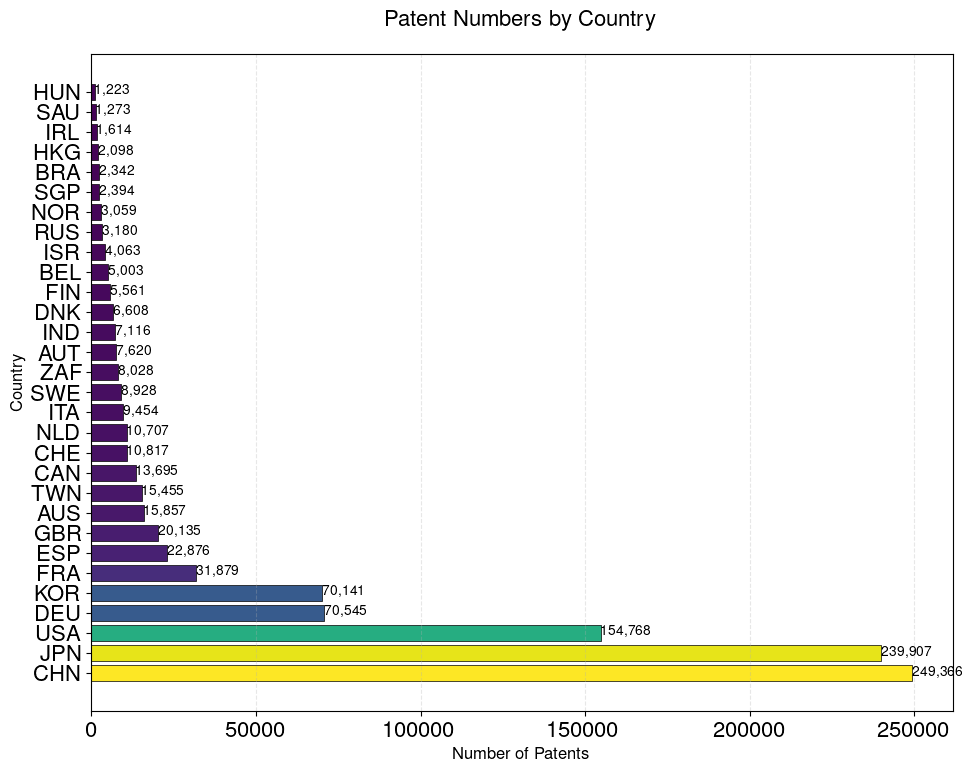

In [ ]:


fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.viridis(df_sorted['num_patents'] / df_sorted['num_patents'].max())
bars = plt.barh(df_sorted['country_code_3digit'], df_sorted['num_patents'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Number of Patents', fontsize=12, fontweight='bold')
ax.set_ylabel('Country', fontsize=12, fontweight='bold')
ax.set_title('Patent Family Numbers by Country', fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()

for i, (idx, row) in enumerate(df_sorted.iterrows()):
    ax.text(row['num_patents'], i, f"  {int(row['num_patents']):,}", 
            va='center', fontsize=10)

plt.tight_layout()
plt.savefig('PATSTAT2025FALL\\results\\patent_numbers_by_country.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import plotly.express as px
# 2. World Map - Patent Quality Index
# Map country codes to ISO-3 format for plotly
country_mapping = {
    'DK': 'DNK', 'CH': 'CHE', 'AU': 'AUS', 'IE': 'IRL', 'BE': 'BEL',
    'GB': 'GBR', 'CA': 'CAN', 'US': 'USA', 'IT': 'ITA', 'FI': 'FIN',
    'SE': 'SWE', 'NL': 'NLD', 'DE': 'DEU', 'NO': 'NOR', 'ES': 'ESP',
    'IN': 'IND', 'FR': 'FRA', 'IL': 'ISR', 'AT': 'AUT', 'SG': 'SGP',
    'CN': 'CHN', 'JP': 'JPN', 'HK': 'HKG', 'RU': 'RUS', 'KR': 'KOR',
    'TW': 'TWN'
}

patent_quality['iso_alpha'] = patent_quality['countries'].map(country_mapping)

# Create choropleth map
fig = px.choropleth(patent_quality,
                    locations='iso_alpha',
                    color='country_patent_quality_index',
                    hover_name='countries',
                    hover_data={'iso_alpha': False,
                               'num_patents': ':,',
                               'country_patent_quality_index': ':.6f'},
                    color_continuous_scale='RdYlBu_r',
                    labels={'country_patent_quality_index': 'Quality Index'},
                    title='World Map of Patent Quality Index')

fig.update_layout(
    title_font_size=20,
    title_x=0.5,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    ),
    height=600,
    width=1200
)

fig.write_html('patent_quality_world_map.html')
fig.show()



In [ ]:
# Save as PNG (requires kaleido)
try:
    fig.write_image('patent_quality_world_map.png', width=1200, height=600, scale=2)
    print("World map saved as 'patent_quality_world_map.png'")
except Exception as e:
    print(f"Could not save PNG. Please install kaleido: pip install kaleido")
    print(f"Error: {e}")

fig.show()

In [ ]:
# # Filter data for those countries and the year range
# filtered_data = num_by_country_year[
#     (num_by_country_year['country'].isin(country_list)) &
#     (num_by_country_year['year'].between(1997, 2023))
# ]

# # Pivot to make years the index and countries the columns
# pivot_data = filtered_data.pivot(index='year', columns='country', values='num_patents')

# # Plot
# plt.figure(figsize=(12, 8))
# for country in country_list:
#     if country in pivot_data.columns:
#         plt.plot(pivot_data.index, pivot_data[country], label=country)

# plt.xlabel("Year")
# plt.ylabel("Number of Patents")
# plt.title("Patent Counts (1997–2022) by Country")
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

In [9]:
import pycountry

# 1. 定义新的转换函数
def convert_2digit_to_3digit_fixed(country_code):
    try:
        # 这里的 lookup 查找非常严格
        country = pycountry.countries.get(alpha_2=country_code)
        if country:
            return country.alpha_3
        else:
            return None
    except:
        return None


In [10]:
patent_quality['country_code_3digit'] = patent_quality['countries'].apply(convert_2digit_to_3digit_fixed)

print(patent_quality[['countries', 'country_code_3digit']].head())

  countries country_code_3digit
0        MV                 MDV
1        CW                 CUW
2        BO                 BOL
3        PG                 PNG
4        DM                 DMA


In [11]:
print(patent_quality[['countries', 'country_code_3digit']].head())
print(f"转换失败的数量: {patent_quality['country_code_3digit'].isna().sum()}")

  countries country_code_3digit
0        MV                 MDV
1        CW                 CUW
2        BO                 BOL
3        PG                 PNG
4        DM                 DMA
转换失败的数量: 9


In [12]:
patent_quality.to_excel("PATSTAT2025FALL\\results\\oecd_patent_quality_country_rankings.xlsx", index=False)

In [35]:
patent_quality.head()

,countries,num_patents,avg_forward_cites_5yr,avg_family_size,avg_claims,avg_generality,avg_generality_oecd,avg_norm_cites,avg_norm_family,avg_norm_claims,...,country_patent_quality_median,country_pqi_oecd,country_pqi_oecd_median,total_citations_5yr,quality_std,quality_std_oecd,earliest_year,latest_year,quality_rank,country_code_3digit
0,MV,1,201.000000,86.000000,15.0,0.729550,0.586353,1.000000,1.000000,0.625000,...,0.867298,0.821720,0.821720,201,,,2011,2011,1,MDV
1,BO,2,20.000000,25.500000,35.5,0.725474,0.797540,0.482601,0.764706,0.556250,...,0.668220,0.672738,0.672738,40,0.2862675623485371,0.24286478840890544,1992,2013,2,BOL
2,PG,1,15.000000,22.000000,29.0,0.533333,0.636126,0.483871,0.814815,0.508772,...,0.611864,0.630930,0.630930,15,,,1995,1995,3,PNG
3,DM,2,15.500000,46.000000,8.0,0.578181,0.794824,0.163932,1.000000,0.307692,...,0.539352,0.589493,0.589493,31,0.16541884108607363,0.14352356493982094,2015,2020,6,DMA
4,SO,6,28.666667,40.833333,23.0,0.469525,0.601068,0.367208,0.848293,0.469644,...,0.499325,0.587867,0.582413,172,0.2405880278237534,0.22685996024988597,1992,2011,4,SOM


### Plot bivariate map

In [11]:
import geopandas as gpd
import mapclassify
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = world[(world.pop_est > 0) & (world.name != "Antarctica")]
patent_quality = pd.read_excel("oecd_patent_quality_country_rankings3.xlsx")
patent_num_ctry = pd.read_csv("countries_patent_count.csv")

C:\Users\admin\AppData\Local\Temp\ipykernel_34108\316131684.py:9: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


In [12]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "axes.labelsize": 14,      # 稍微調小，避免喧賓奪主
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300,         # 增加 DPI 提升清晰度
    "savefig.bbox": "tight",   # 保存時自動去白邊
    "savefig.pad_inches": 0.1  # 減少邊距
})

plt.rcParams['text.latex.preamble'] = r'''
    \usepackage{helvet}
    \renewcommand{\familydefault}{\sfdefault}
    \usepackage{sansmath}
    \sansmath
    \usepackage{anyfontsize}
    \newcommand{\darrow}{\ensuremath{\rightarrow}} % 定義一個箭頭命令方便使用
'''

In [13]:
# 按照專利數量排序
country_stats = patent_quality.sort_values('num_patents', ascending=False).copy()

# 計算累計百分比
country_stats['cumulative_percent'] = country_stats['num_patents'].cumsum() / country_stats['num_patents'].sum()

# 找出貢獻了前 99% 專利的國家列表
pareto_countries = country_stats[country_stats['cumulative_percent'] <= 0.99]['countries_3digit'].tolist()
print(f"根據 Top 99% 規則，保留的國家數量: {len(pareto_countries)}")

# 創建繪圖數據副本
plot_df = patent_quality.copy()

# 【關鍵修改】：不在名單內的國家視為噪聲 (設置為 NaN)
# 這比直接 drop 掉更好，因為 merge 時可以保留地圖形狀（顯示為灰色）
mask_noise = ~plot_df['countries_3digit'].isin(pareto_countries)
plot_df.loc[mask_noise, ['num_patents', 'country_patent_quality_index']] = np.nan

根據 Top 99% 規則，保留的國家數量: 46


In [14]:
# def get_quantile_class(series, k=3):
#     # 只對非空數據 (即 Top 99% 的國家) 進行分位數計算
#     valid_data = series.dropna()
#     if len(valid_data) == 0:
#         return np.full(len(series), -1)
    
#     # 計算分位數斷點
#     classifier = mapclassify.Quantiles(valid_data, k=k)
    
#     # 應用分類，如果是 NaN 則返回 -1
#     return series.apply(lambda x: classifier(x)[0] if pd.notnull(x) else -1)

# # 計算等級 (0, 1, 2) 或 -1 (噪聲)
# plot_df['qty_class'] = get_quantile_class(plot_df['num_patents'])
# plot_df['qual_class'] = get_quantile_class(plot_df['country_patent_quality_index'])
def get_natural_breaks_class(series, k=3):
    """
    使用 Jenks Natural Breaks 算法進行分類。
    該算法尋找數據中的自然斷點，使組內方差最小，組間方差最大。
    適合處理非正態分佈的專利數據。
    """
    # 只對非空數據 (即 Top 99% 的國家) 進行計算
    valid_data = series.dropna()
    if len(valid_data) == 0:
        return np.full(len(series), -1)
    
    # 【核心修改】：使用 NaturalBreaks
    try:
        classifier = mapclassify.NaturalBreaks(valid_data, k=k)
        print(f"Natural Breaks ({series.name}) 斷點: {classifier.bins}")
    except Exception as e:
        print(f"Natural Breaks 計算失敗 (可能是數據點太少)，回退到 Quantiles: {e}")
        classifier = mapclassify.Quantiles(valid_data, k=k)
    
    # 應用分類，如果是 NaN 則返回 -1
    return series.apply(lambda x: classifier(x)[0] if pd.notnull(x) else -1)

# 計算等級 (0, 1, 2) 或 -1 (噪聲)
print("正在計算 Natural Breaks...")
plot_df['qty_class'] = get_natural_breaks_class(plot_df['num_patents'])
plot_df['qual_class'] = get_natural_breaks_class(plot_df['country_patent_quality_index'])

正在計算 Natural Breaks...
Natural Breaks (num_patents) 斷點: [ 14638.  52206. 118445.]
Natural Breaks (country_patent_quality_index) 斷點: [0.20766153 0.23702453 0.30254452]


In [15]:
# 定義顏色板 (Pink-Blue 方案)
# 順序: Low-Low, Low-Med, Low-High ... High-High
# 索引計算: idx = qual_class * 3 + qty_class
bivariate_colors = [
    "#d9d9d9", "#b0d5df", "#64acbe", # Low Quality 行 (左->右: 數量增)
    "#e4acac", "#ad9ea5", "#627f8c", # Med Quality 行
    "#c85a5a", "#985356", "#574249"  # High Quality 行
]

def assign_color(row):
    if row['qty_class'] == -1 or row['qual_class'] == -1:
        return None # 稍後在繪圖時處理為默認灰色
    idx = int(row['qual_class'] * 3 + row['qty_class'])
    # 防止索引越界
    if 0 <= idx < len(bivariate_colors):
        return bivariate_colors[idx]
    return None

plot_df['color'] = plot_df.apply(assign_color, axis=1)


In [16]:
# ==========================================
# 4. 合併地圖與數據 (Merge)
# ==========================================
world_merged = world.merge(plot_df, left_on='iso_a3', right_on='countries_3digit', how='left')
world_merged['color'] = world_merged['color'].fillna('#f0f0f0') # 默認灰色填充

# 嘗試投影轉換 (Robinson)
try:
    world_robinson = world_merged.to_crs('+proj=eqearth')
except Exception as e:
    print(f"投影轉換失敗 (可能缺少 pyproj)，使用默認投影: {e}")
    world_robinson = world_merged

# ==========================================
# 5. 繪圖與自定義矩陣圖例 (Legend)
# ==========================================

# ==========================================
# [修改] 圖例函數 - 使用 LaTeX 與 無邊框設計
# ==========================================
def add_bivariate_legend(ax, colors, x_label='Quantity', y_label='Quality'):
    # 位置調整：這部分在下面的"修改4"中具體調用時微調，這裡主要改樣式
    # 這裡的坐標是佔位符，實際由調用時決定
    cax = ax.inset_axes([0.12, 0.22, 0.20, 0.20], transform=ax.transAxes)
    
    data_grid = np.arange(9).reshape(3, 3)
    cmap = ListedColormap(bivariate_colors)
    cax.imshow(data_grid, cmap=cmap, origin='lower', aspect='equal')
    cax.tick_params(axis='both', which='both', length=0, pad=4)
    cax.set_xticks([0, 2])
    cax.set_xticklabels([r'\textbf{Low}', r'\textbf{High}'], fontsize=9)
    cax.set_yticks([0, 2])
    cax.set_yticklabels([r'\textbf{Low}', r'\textbf{High}'], fontsize=10, rotation=90, va='center')
    cax.set_xlabel(r"Patent Number $\rightarrow$", fontsize=9, labelpad=2)
    cax.set_ylabel(r"Patent Quality $\rightarrow$", fontsize=9, labelpad=2)
    for spine in cax.spines.values(): spine.set_visible(False)
        
    return cax

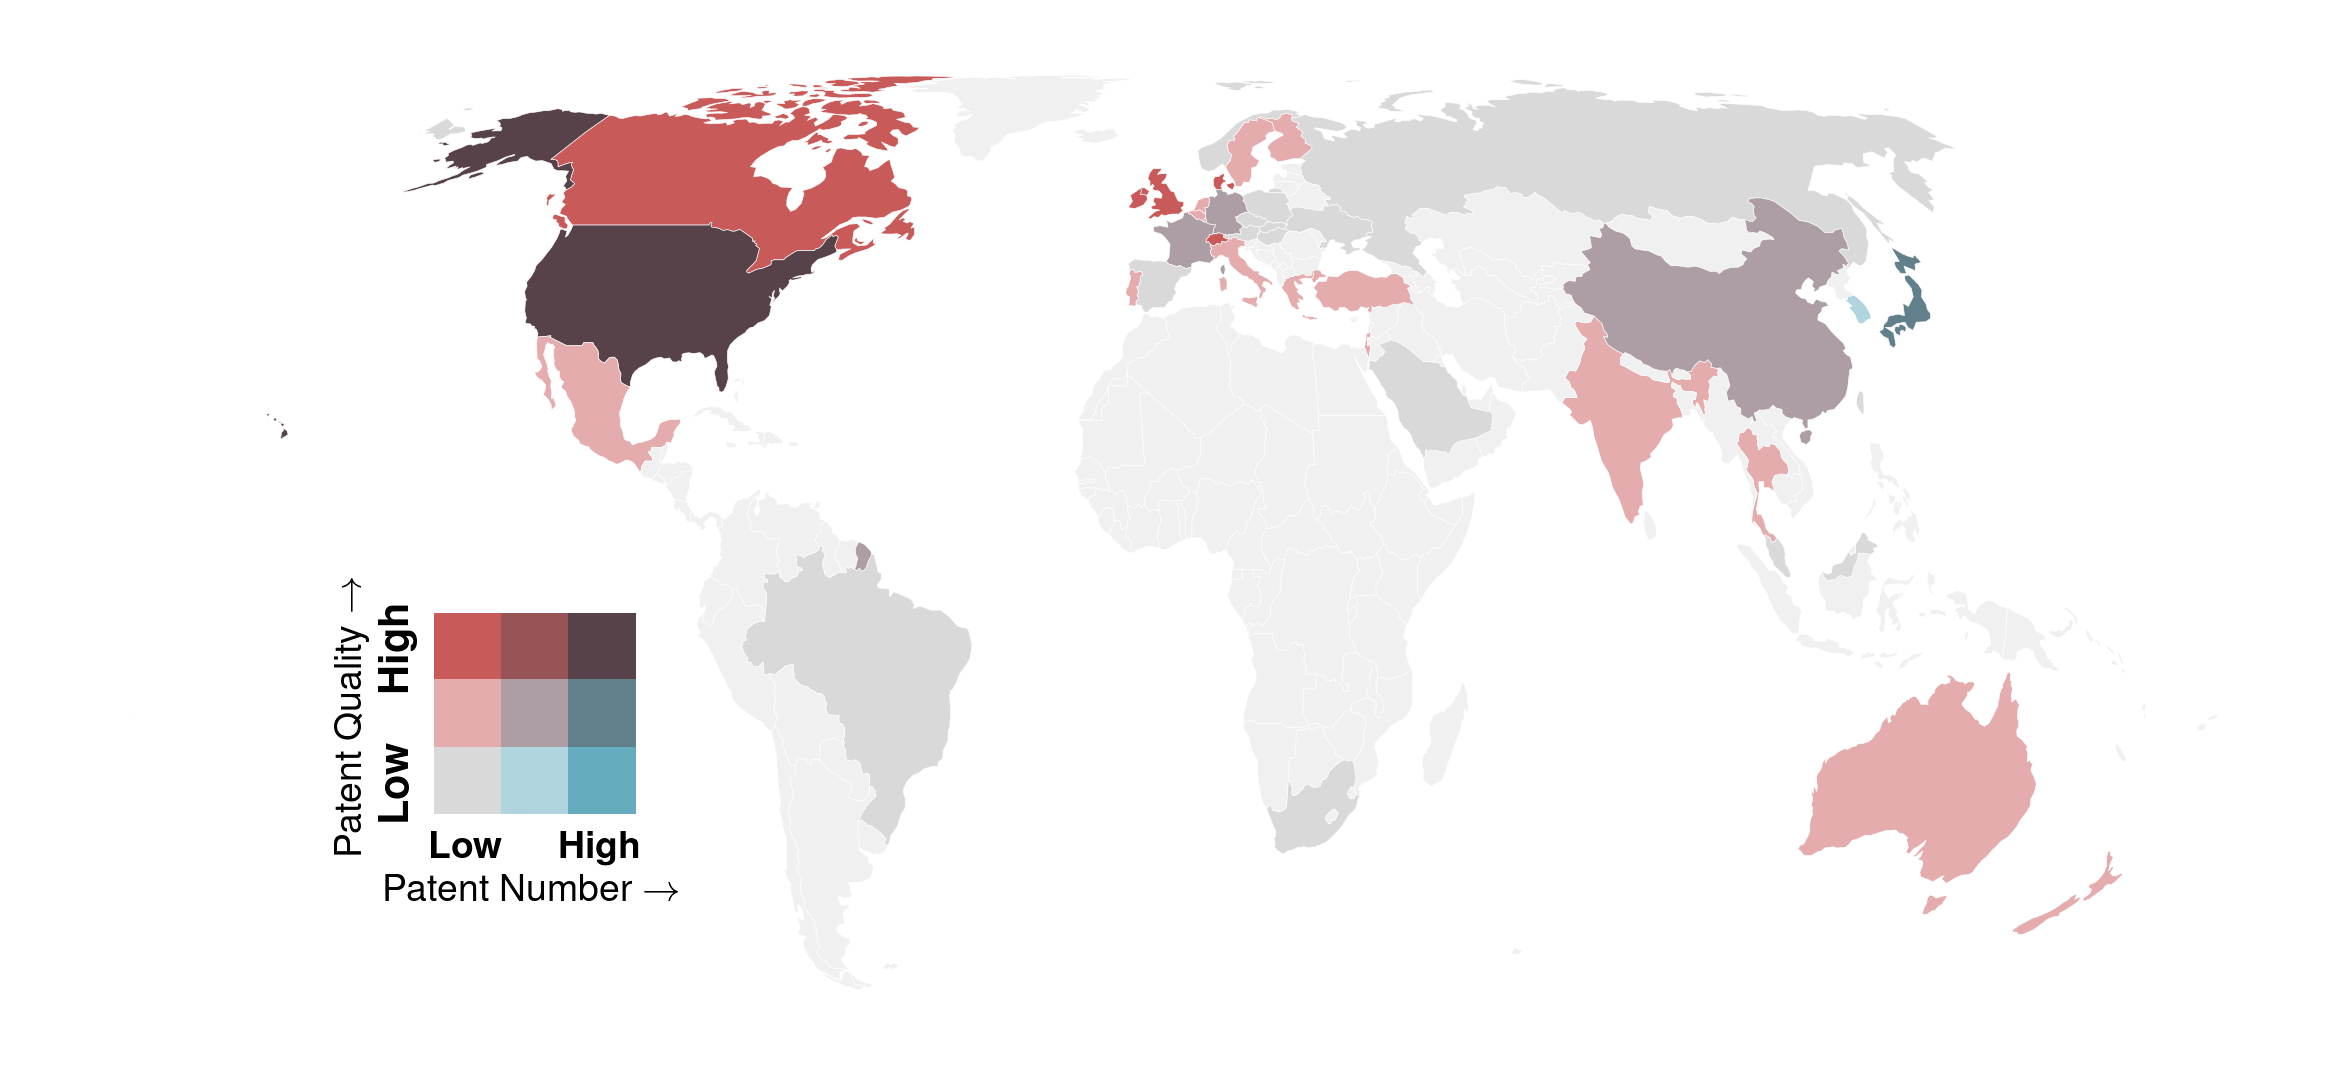

In [17]:
# --- 開始繪圖 ---
fig, ax = plt.subplots(1, 1, figsize=(8, 12)) 

world_robinson.plot(
    ax=ax,
    color=world_robinson['color'],
    edgecolor='white',  # 保持白色邊框
    linewidth=0.15,     # 【關鍵】從 0.5 改為 0.15 或 0.2，這會讓地圖顯得非常精緻
)

# 添加正確的矩陣圖例
add_bivariate_legend(
    ax, 
    colors=bivariate_colors, 
    x_label='Patent Number', 
    y_label='Patent Quality Index'
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

### another plot

In [14]:

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 設置樣式
# ==========================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "figure.dpi": 300,
})


In [ ]:

# ==========================================
# 2. 數據讀取與處理
# ==========================================
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = world[(world.pop_est > 0) & (world.name != "Antarctica")]

# 讀取數據 (模擬或真實)
try:
    patent_quality = pd.read_excel("oced_patent_quality_country_rankings4.xlsx")
    print("成功讀取 Excel。")
except:
    print("使用模擬數據。")
    np.random.seed(42)
    patent_quality = pd.DataFrame({
        'countries_3digit': world['iso_a3'].tolist(),
        'num_patents': np.random.exponential(scale=2000, size=len(world)),
        'country_patent_quality_index': np.random.normal(0.5, 0.15, size=len(world))
    })

# 數據過濾 (Top 99%)
if not patent_quality.empty:
    stats = patent_quality.sort_values('num_patents', ascending=False)
    stats['cumsum'] = stats['num_patents'].cumsum() / stats['num_patents'].sum()
    valid_countries = stats[stats['cumsum'] <= 0.99]['countries_3digit'].tolist()
    
    # 只保留有效國家用於繪製氣泡
    plot_df = patent_quality[patent_quality['countries_3digit'].isin(valid_countries)].copy()
else:
    plot_df = patent_quality.copy()

# 合併數據
world_merged = world.merge(plot_df, left_on='iso_a3', right_on='countries_3digit', how='left')

# 投影轉換 (Equal Earth 適合氣泡圖，保持面積比例)
world_proj = world_merged.to_crs('+proj=eqearth')

使用模擬數據。


C:\Users\admin\AppData\Local\Temp\ipykernel_46448\544271895.py:4: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


In [20]:
# ==========================================
# 3. 計算氣泡位置與大小
# ==========================================
# 計算每個國家的代表點 (Representative Point) 作為氣泡中心
# 注意：centroid 有時會落在國界外(如形狀彎曲的國家)，representative_point 總是在境內
world_proj['centroid'] = world_proj.geometry.representative_point()

# 提取繪圖數據 (去除 NaN)
bubble_data = world_proj.dropna(subset=['num_patents', 'country_patent_quality_index'])

# 氣泡大小縮放 (關鍵步驟)
# 面積應該與數量成正比，所以半徑應該與數量的平方根成正比
# s = scale * (value / max_value)
max_val = bubble_data['num_patents'].max()
bubble_data['size'] = 1000 * (bubble_data['num_patents'] / max_val) # 1000是最大氣泡的像素面積

c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


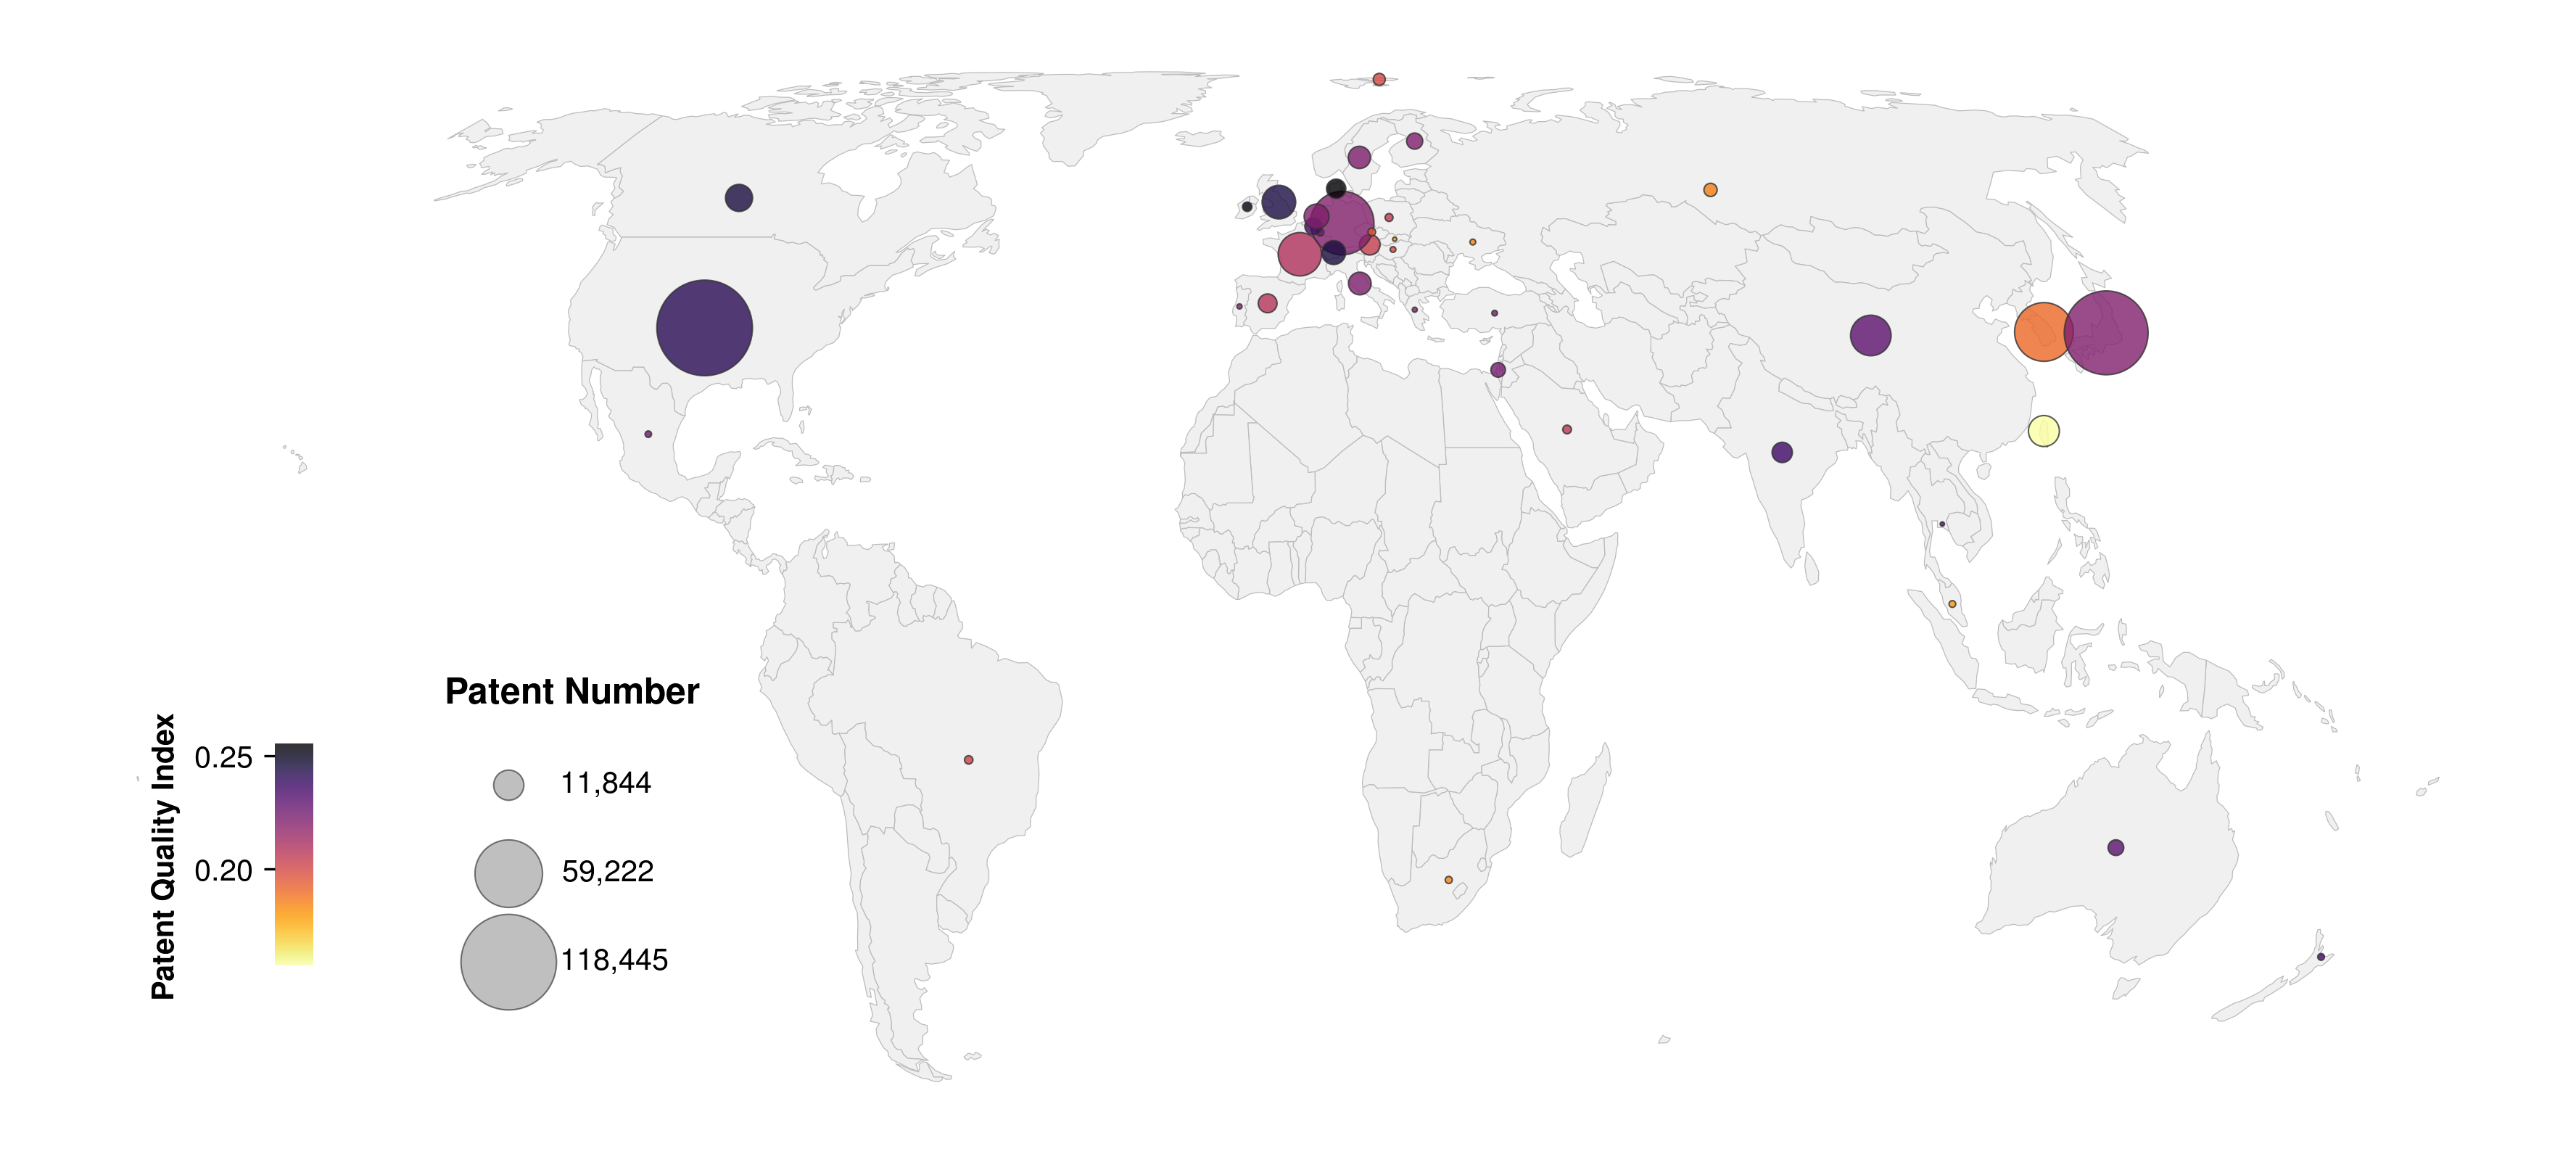

In [21]:
# ==========================================
# 4. 繪圖
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# A. 繪製底圖 (改進方案：突出行政邊界)
# 修改說明：
# edgecolor='#bbbbbb': 使用中灰色代替白色，讓國界線清晰可見
# linewidth=0.3: 線條變細，避免喧賓奪主，保持地圖的精緻感
world_proj.plot(
    ax=ax,
    color='#f0f0f0',
    edgecolor='#bbbbbb', 
    linewidth=0.3
)

# B. 繪製氣泡 (散點圖)
# c=質量 (顏色), s=數量 (大小)
sc = ax.scatter(
    x=bubble_data['centroid'].x,
    y=bubble_data['centroid'].y,
    s=bubble_data['size'],
    c=bubble_data['country_patent_quality_index'],
    cmap='inferno_r', # 使用 inferno_r (黃->紅->黑)，高質量為深色，低質量為亮色
    alpha=0.8,      # 透明度，防止重疊完全遮擋
    edgecolor='#333333',
    linewidth=0.5,
    zorder=2
)

# ==========================================
# 5. 雙圖例設計 (核心難點)
# ==========================================

# --- 圖例 1: 顏色條 (質量) ---
# 使用 inset_axes 在地圖內部創建一個子圖來放置 colorbar
# 位置 [x, y, width, height] 是相對於 ax 的比例坐標
# 這裡將其放在左下角，位於大小圖例的上方
cax = ax.inset_axes([0.1, 0.15, 0.015, 0.2]) 

# 繪製 colorbar 到這個子圖上
cbar = plt.colorbar(
    sc, 
    cax=cax, 
    orientation='vertical'
)
# 將標籤和刻度放在左側，讓視覺重心集中在左邊緣
cbar.set_label(r'\textbf{Patent Quality Index}', labelpad=5, fontsize=10)
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')
cbar.outline.set_visible(False) 

# --- 圖例 2: 大小圓圈 (數量) ---
# 手動創建幾個示例圓圈
sizes = [max_val * 0.1, max_val * 0.5, max_val] # 10%, 50%, 100% 的值
labels = [f'{int(s):,}' for s in sizes]
# 轉換為繪圖用的 size (像素面積)
plot_sizes = [1000 * (s / max_val) for s in sizes]

# 在圖表空白處繪製大小圖例
# 使用 legend_elements 的替代方案，直接畫 dummy points
legend_markers = []
for s in plot_sizes:
    legend_markers.append(plt.scatter([], [], s=s, c='gray', alpha=0.5, edgecolor='black', linewidth=0.5))

# 放置大小圖例 (放在左下角，Colorbar 的下方)
leg = ax.legend(
    legend_markers, 
    labels, 
    title=r"\textbf{Patent Number}",
    loc='lower left',
    frameon=False,
    labelspacing=2,
    borderpad=1.0,    # 增加邊界填充
    bbox_to_anchor=(0.15, 0.1) # 調整位置錨點
)

# 調整標題與佈局
ax.set_axis_off()
plt.tight_layout()

plt.show()

In [13]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# ==========================================
# 1. 學術風格設置 (Academic Style)
# ==========================================
# 使用 seaborn-paper 風格，適合論文排版
plt.style.use('seaborn-v0_8-paper')

# 字體與 LaTeX 設置
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",             # 學術論文常用襯線體 (Times New Roman 風格)
    "font.serif": ["Times New Roman", "Computer Modern Roman"],
    "font.size": 10,
    "axes.titlesize": 14,
    "figure.dpi": 300,                  # 高分辨率用於出版
    "figure.figsize": (16, 8),          # 寬幅佈局適合雙圖並排
})


In [17]:
# ==========================================
# 2. 數據準備 (2×2 figure: green patents, high-influence, neighbor, quality)
# ==========================================
import geopandas as gpd
import matplotlib.colors as mcolors
import mapclassify

world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = world[(world.pop_est > 0) & (world.name != "Antarctica")]

# --- (a) Green patent family counts by country ---
patent_quality = pd.read_excel("PATSTAT2025FALL\\results\\oecd_patent_quality_country_rankings.xlsx")

# --- (b) High-influence patent family counts by country ---
hi_df = pd.read_csv("PATSTAT2025FALL\\output\\hi_patent_country_year_complete.csv")
hi_total = hi_df.groupby('country_code_3digit')['num_hi_patents'].sum().reset_index()

# --- (c) Neighbor patent family counts by country ---
nb_df = pd.read_csv("PATSTAT2025FALL\\output\\neighbor_patent_country_year_complete.csv")
nb_total = nb_df.groupby('country_code_3digit')['num_neighbor_patents'].sum().reset_index()

# --- (d) Green patent leadership index (total across all years) ---
idx_df = pd.read_csv("E:/us_china_compare/ClimateDataAnalysis/out/index_by_total_frac.csv")
idx_df['country_code_3digit'] = idx_df['country'].apply(convert_2digit_to_3digit_fixed)
idx_df = idx_df.dropna(subset=['country_code_3digit'])

# --- Same top-99% patent volume filter as other subplots ---
if not patent_quality.empty:
    stats_idx = patent_quality.sort_values('inventor_frac_patents', ascending=False).copy()
    stats_idx['cumsum'] = stats_idx['inventor_frac_patents'].cumsum() / stats_idx['inventor_frac_patents'].sum()
    valid_idx = stats_idx[stats_idx['cumsum'] <= 0.995]['country_code_3digit'].tolist()
    plot_idx = idx_df[idx_df['country_code_3digit'].isin(valid_idx)].copy()
else:
    plot_idx = idx_df.copy()

# --- Merge each dataset with the world map ---
world_vol = world.merge(patent_quality, left_on='iso_a3', right_on='country_code_3digit', how='left')
world_hi  = world.merge(hi_total,       left_on='iso_a3', right_on='country_code_3digit', how='left')
world_nb  = world.merge(nb_total,       left_on='iso_a3', right_on='country_code_3digit', how='left')
world_idx = world.merge(plot_idx,        left_on='iso_a3', right_on='country_code_3digit', how='left')

# --- Project ---
world_vol_proj = world_vol.to_crs('+proj=eqearth')

world_hi_proj  = world_hi.to_crs('+proj=eqearth')
world_nb_proj  = world_nb.to_crs('+proj=eqearth')
world_idx_proj = world_idx.to_crs('+proj=eqearth')


C:\Users\admin\AppData\Local\Temp\ipykernel_104248\1061408755.py:8: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


title: \textbf{(a) Climate-Related Patent Families}, bounds: [0.0067114093959731, 3560.908062850851, 14350.11129676433, 31935.30325727024, 55822.38901224561, 112980.506741087, 131166.1581671756]


C:\Users\admin\AppData\Local\Temp\ipykernel_104248\111240875.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


title: \textbf{(b) High-Influential Climate Patent Families}, bounds: [1.0, 1353.0, 5623.0, 12427.0, 36441.0, 98721.0, 145013.0]


C:\Users\admin\AppData\Local\Temp\ipykernel_104248\111240875.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


title: \textbf{(c) Non-Climate Neighbor Patent Families}, bounds: [1.0, 23924.0, 79284.0, 151939.0, 434478.0, 1349769.0, 1631825.0]


C:\Users\admin\AppData\Local\Temp\ipykernel_104248\111240875.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


title: \textbf{(d)   Climate Innovation Index}, bounds: [-0.2233054856425633, -0.1506592348361682, 0.4542206159602964, 0.8171183526678564, 1.0558863223191428, 1.3736079092216842, 1.739955801135208]


C:\Users\admin\AppData\Local\Temp\ipykernel_104248\111240875.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


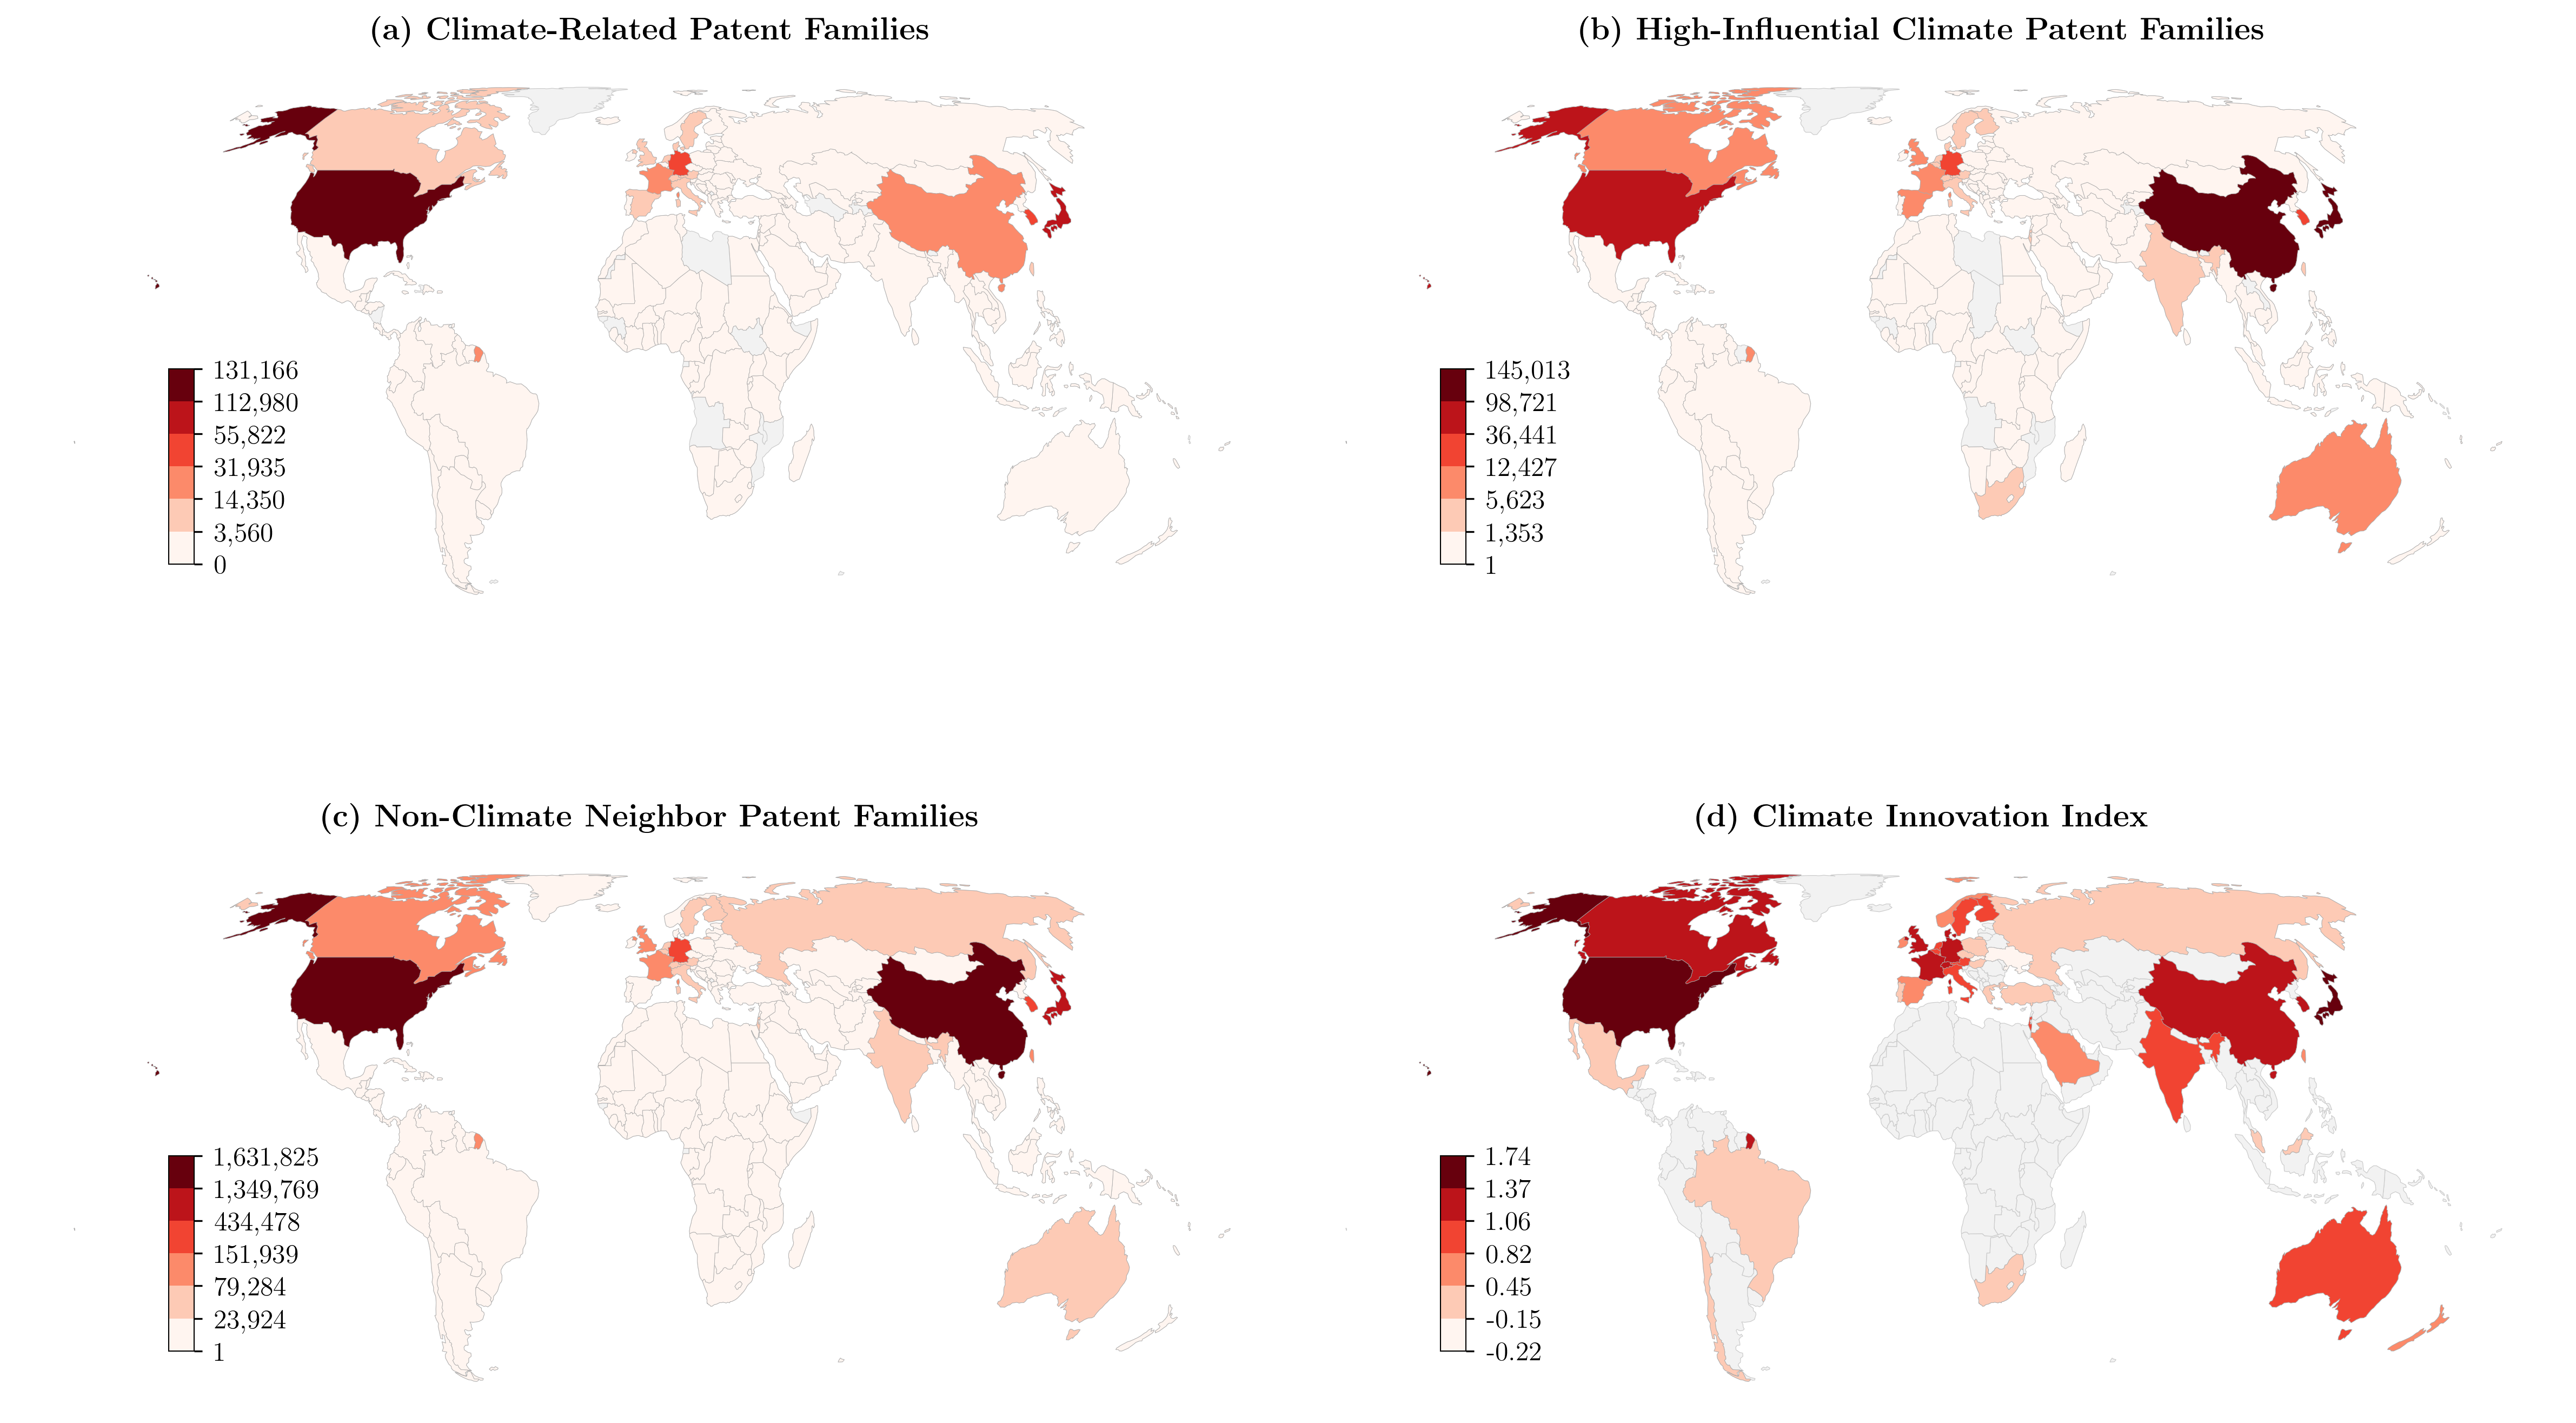

In [19]:
# ==========================================
# 3. Helper: discrete colorbar for a single subplot
# ==========================================
def plot_choropleth(ax, world_proj, col, cmap_name, title, k=6, fmt_int=True,
                    filter_positive=True, float_fmt=".4f"):
    """Plot a choropleth with discrete Natural Breaks colorbar."""
    ax.set_axis_off()
    world_proj.plot(ax=ax, color='#f2f2f2', edgecolor='#cccccc', linewidth=0.3)

    data = world_proj.dropna(subset=[col])
    valid = data[data[col] > 0][col] if filter_positive else data[col]
    if valid.empty:
        ax.set_title(title, fontsize=14, pad=10)
        return

    classifier = mapclassify.NaturalBreaks(valid, k=k)
    breaks = classifier.bins
    bounds = [valid.min()] + list(breaks)
    print(f"title: {title}, bounds: {bounds}")
    cmap = plt.cm.get_cmap(cmap_name)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    data.plot(
        ax=ax, column=col, cmap=cmap_name,
        classification_kwds={'bins': breaks}, scheme='user_defined',
        edgecolor='#aaaaaa', linewidth=0.2, legend=False,
    )

    cax = ax.inset_axes([0.12, 0.1, 0.02, 0.35])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar = plt.colorbar(sm, cax=cax, orientation='vertical', spacing='uniform')
    cbar.outline.set_linewidth(0.5)
    cbar.ax.tick_params(labelsize=12)
    if fmt_int:
        cbar.set_ticks(bounds)
        cbar.set_ticklabels([f'{int(b):,}' for b in bounds])
    else:
        cbar.set_ticks(bounds)
        cbar.set_ticklabels([f'{b:{float_fmt}}' for b in bounds])

    ax.set_title(title, fontsize=14, pad=10)

# ==========================================
# 4. 2×2 Figure
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (1,1) Climate patent families — Blues
plot_choropleth(
    axes[0, 0], world_vol_proj, 'inventor_frac_patents', 'Reds',
    r'\textbf{(a) Climate-Related Patent Families}',
)

# (1,2) High-influential climate patent families — Oranges
plot_choropleth(
    axes[0, 1], world_hi_proj, 'num_hi_patents', 'Reds',
    r'\textbf{(b) High-Influential Climate Patent Families}',
)

# (2,1) Non-climate neighbor patent families — Purples
plot_choropleth(
    axes[1, 0], world_nb_proj, 'num_neighbor_patents', 'Reds',
    r'\textbf{(c) Non-Climate Neighbor Patent Families}',
)

# (2,2) Green patent leadership index (total)
plot_choropleth(
    axes[1, 1], world_idx_proj, 'index_score', 'Reds',
    r'\textbf{(d)   Climate Innovation Index}',
    fmt_int=False, filter_positive=False, float_fmt='.2f',
)

plt.subplots_adjust(wspace=0.0, hspace=0.0, left=0.01, right=0.99, bottom=0.02, top=0.99)
plt.show()

### By year

In [18]:
num_by_country_year = pd.read_csv('countries_patent_count.csv', keep_default_na=False)


In [19]:
num_by_country_year['countries_3digit'] = num_by_country_year['countries'].apply(convert_2digit_to_3digit_fixed)
num_by_country_year.head()

,countries,earliest_year,num_patents,countries_3digit
0,AD,1988,1,AND
1,AD,1989,1,AND
2,AD,2010,1,AND
3,AD,2011,3,AND
4,AD,2014,1,AND


In [20]:
start_year = 1987
end_year = num_by_country_year['earliest_year'].max()

years = pd.RangeIndex(start_year, end_year + 1)
countries = num_by_country_year['countries_3digit'].unique()

full_index = pd.MultiIndex.from_product(
    [countries, years],
    names=['countries_3digit', 'earliest_year']
)

# make index unique by aggregating (sum here; use first/mean if preferred)
agg = (
    num_by_country_year
    .groupby(['countries_3digit', 'earliest_year'], as_index=False)
    .sum(numeric_only=True)
)

expanded = (
    agg
    .set_index(['countries_3digit', 'earliest_year'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

print(expanded.head())

  countries_3digit  earliest_year  num_patents
0              AND           1987            0
1              AND           1988            1
2              AND           1989            1
3              AND           1990            0
4              AND           1991            0


In [42]:
expanded.to_excel('expanded_patent_count8722.xlsx', index=False)

C:\Users\admin\AppData\Local\Temp\ipykernel_18900\3901587194.py:25: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


Natural Breaks classification bins: [  5003.  15857.  31879.  70545. 154768. 249366.]


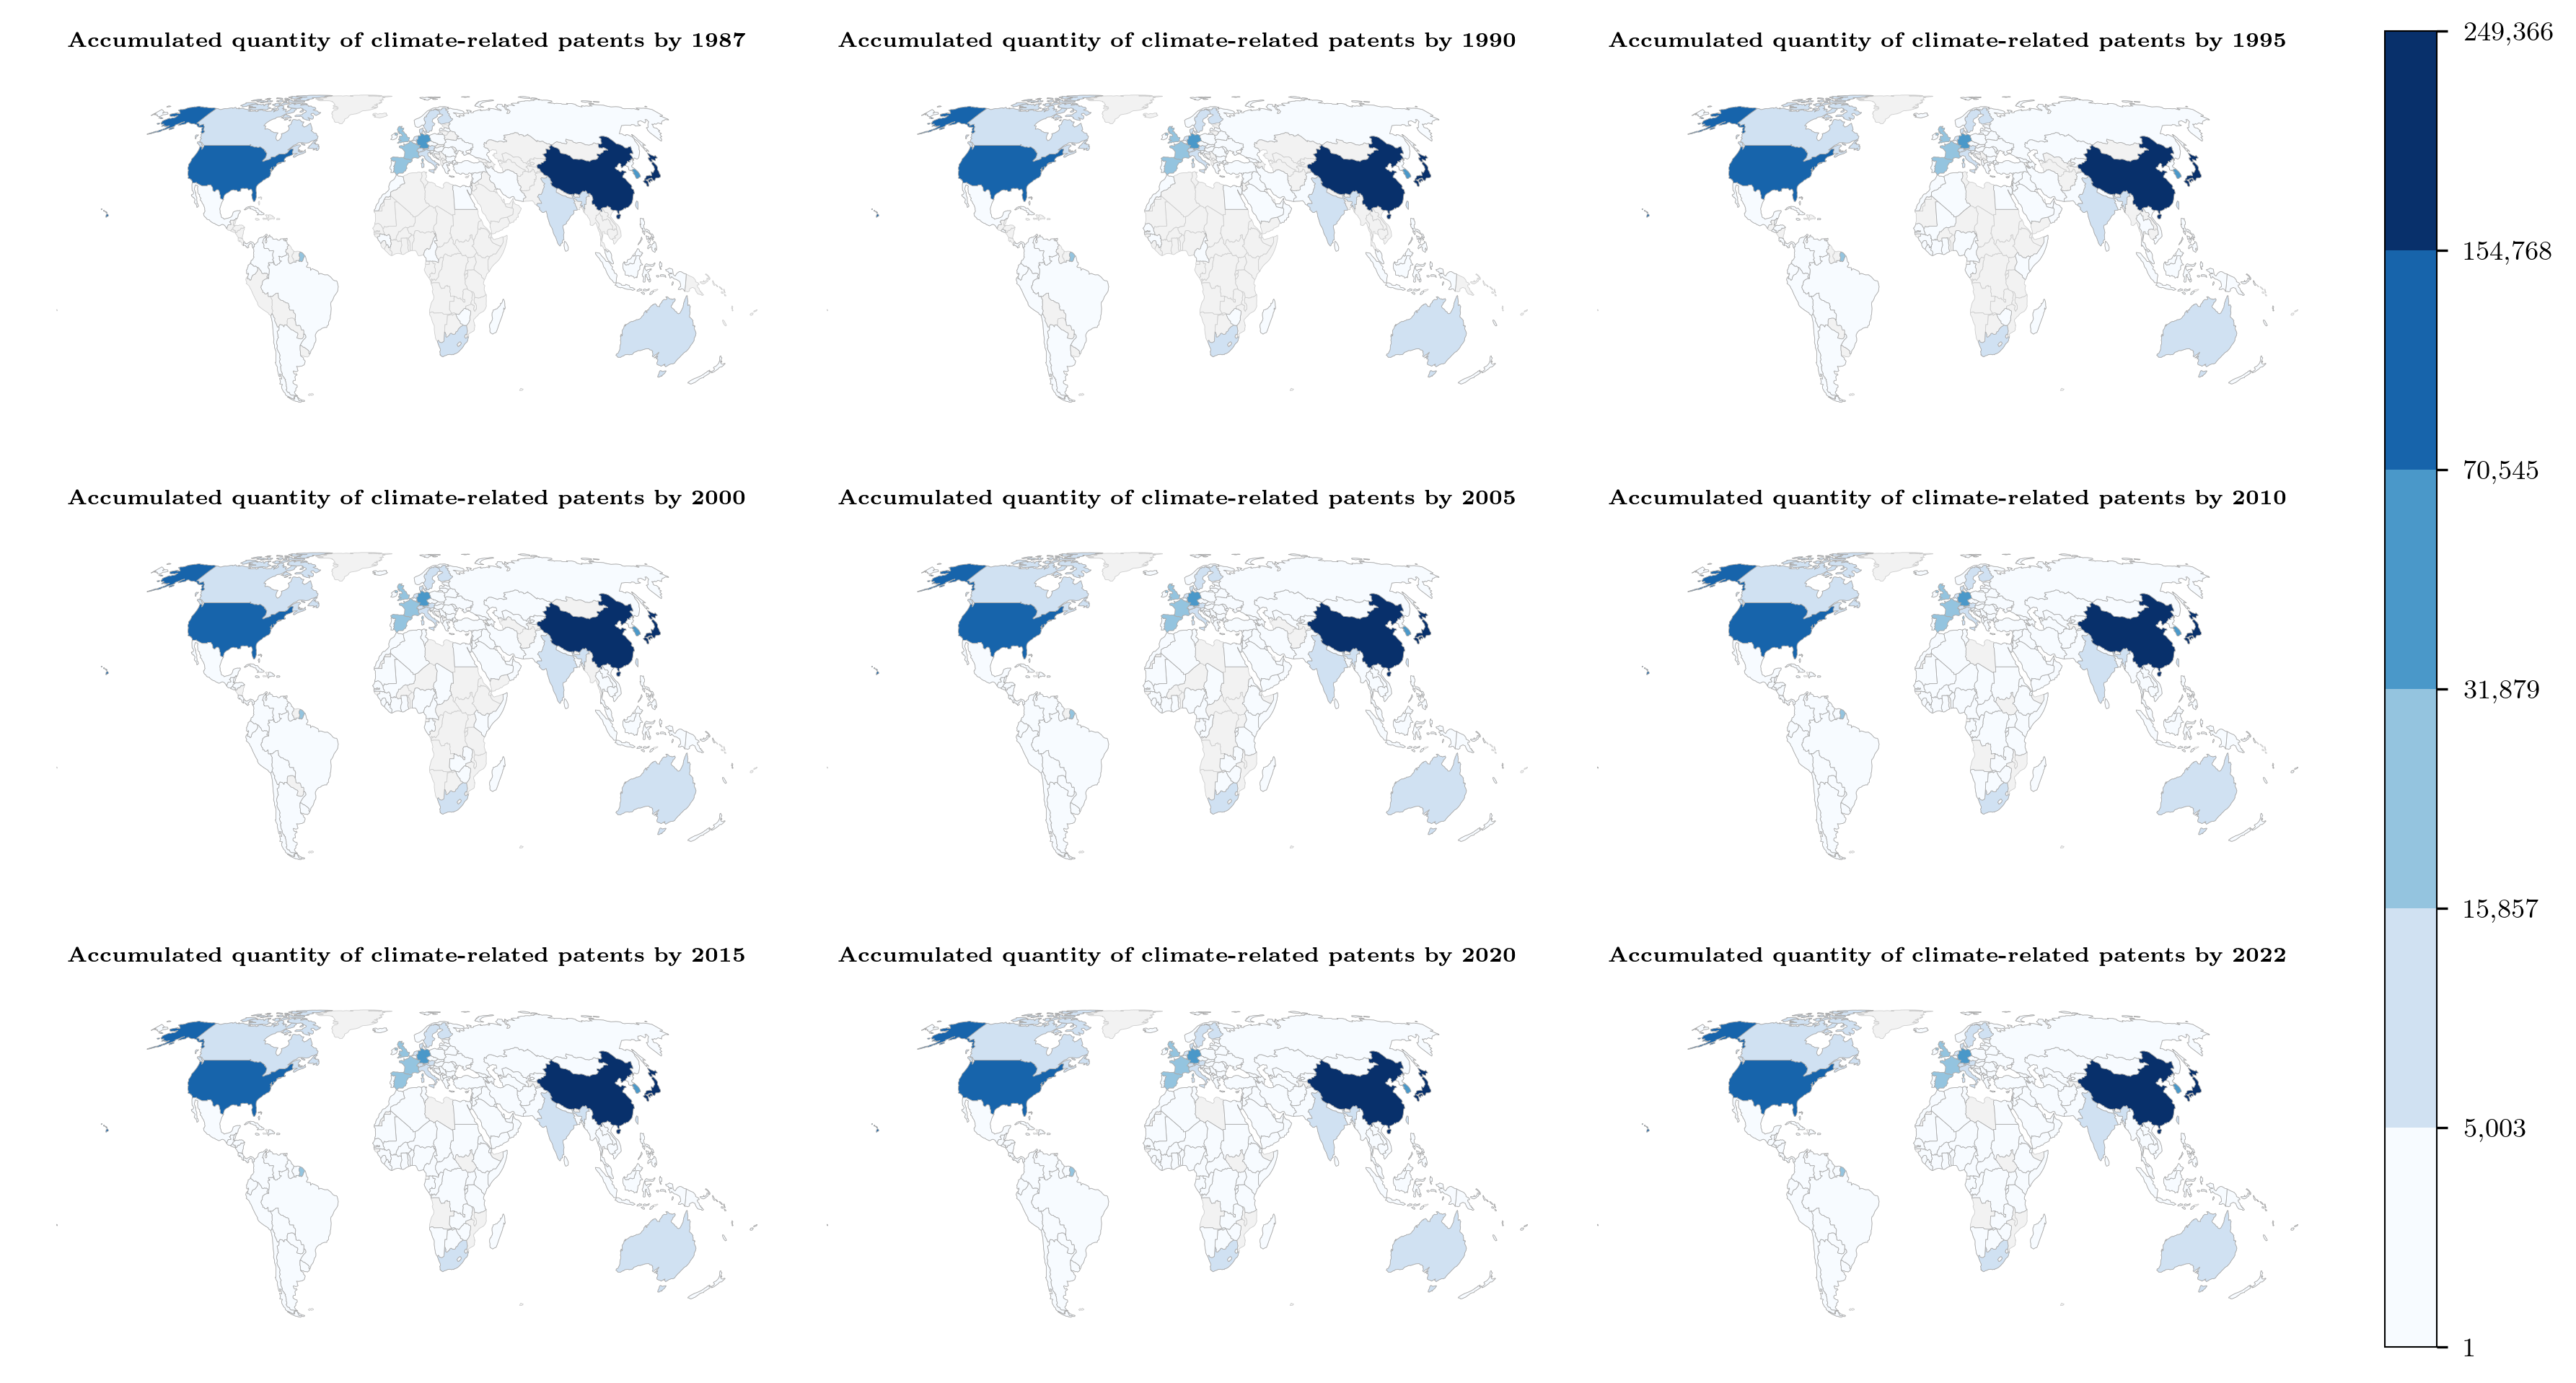

In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import mapclassify

# ==========================================
# 1. 設置學術風格
# ==========================================
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Computer Modern Roman"],
    "font.size": 11,
    "axes.titlesize": 12,
    "figure.dpi": 300,
})

# ==========================================
# 2. 數據處理
# ==========================================
# 讀取地圖
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = world[(world.pop_est > 0) & (world.name != "Antarctica")]

# 讀取專利數據
df = pd.read_excel("PATSTAT2025FALL\\results\\oecd_patent_quality_country_rankings.xlsx")

# 確保年份列名正確
year_col = 'earliest_year' 
if year_col not in df.columns:
    for col in df.columns:
        if 'year' in col.lower():
            year_col = col
            break

# 定義要展示的時間節點
target_years = [1987, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2022]

# 收集所有年份的累計專利數據用於計算全局 natural breaks
all_accumulated_data = []
for year in target_years:
    df_accumulated = df[df[year_col] <= year].groupby('country_code_3digit')['num_patents'].sum().reset_index()
    df_accumulated['year'] = year
    all_accumulated_data.append(df_accumulated)

df_all = pd.concat(all_accumulated_data, ignore_index=True)

# 計算全局 Natural Breaks (使用所有年份的數據)
valid_patents = df_all[df_all['num_patents'] > 0]['num_patents']
classifier = mapclassify.NaturalBreaks(valid_patents, k=6)
breaks = classifier.bins

print(f"Natural Breaks classification bins: {breaks}")

# ==========================================
# 3. 繪製 Small Multiples (3行3列)
# ==========================================
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for i, year in enumerate(target_years):
    ax = axes[i]
    
    # --- A. 計算截止到該年份的累計數量 (Accumulated Stock) ---
    df_accumulated = df[df[year_col] <= year].groupby('country_code_3digit')['num_patents'].sum().reset_index()
    
    # 合併到地圖數據
    world_merged = world.merge(df_accumulated, left_on='iso_a3', right_on='country_code_3digit', how='left')
    
    # 投影轉換 (Equal Earth)
    world_proj = world_merged.to_crs('+proj=eqearth')
    
    # --- B. 繪圖 ---
    # 1. 繪製底圖 (淺灰)
    world_proj.plot(ax=ax, color='#f2f2f2', edgecolor='#cccccc', linewidth=0.2)
    
    # 2. 繪製數據 (Choropleth with Natural Breaks)
    world_proj.dropna(subset=['num_patents']).plot(
        ax=ax,
        column='num_patents',
        cmap='Blues',
        classification_kwds={'bins': breaks},  # 使用全局統一的斷點
        scheme='user_defined',  # 使用自定義斷點
        edgecolor='#aaaaaa',
        linewidth=0.2,
        legend=False
    )
    
    # 3. 設置標題和移除坐標軸
    ax.set_title(fr"\textbf{{Accumulated quantity of climate-related patents by {year}}}", fontsize=7, pad=2)
    ax.set_axis_off()

# ==========================================
# 4. 添加統一 Colorbar (使用 Natural Breaks 的斷點)
# ==========================================
cax = fig.add_axes([0.92, 0.12, 0.02, 0.76])
cmap = plt.cm.Blues
patent_min = valid_patents.min()
bounds = [patent_min] + list(breaks)
norm_discrete = mcolors.BoundaryNorm(bounds, cmap.N)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_discrete)
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation='vertical', spacing='uniform')

cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(labelsize=9)

cbar.set_ticks(bounds)
cbar.set_ticklabels([f'{int(b):,}' for b in bounds])

# 調整佈局
plt.subplots_adjust(wspace=0.0, hspace=0.05, left=0.01, right=0.9, bottom=0.1)

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_18900\471695100.py:26: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


High-influence Natural Breaks bins: [ 1398.  5617. 12307. 31280. 73032. 98712.]


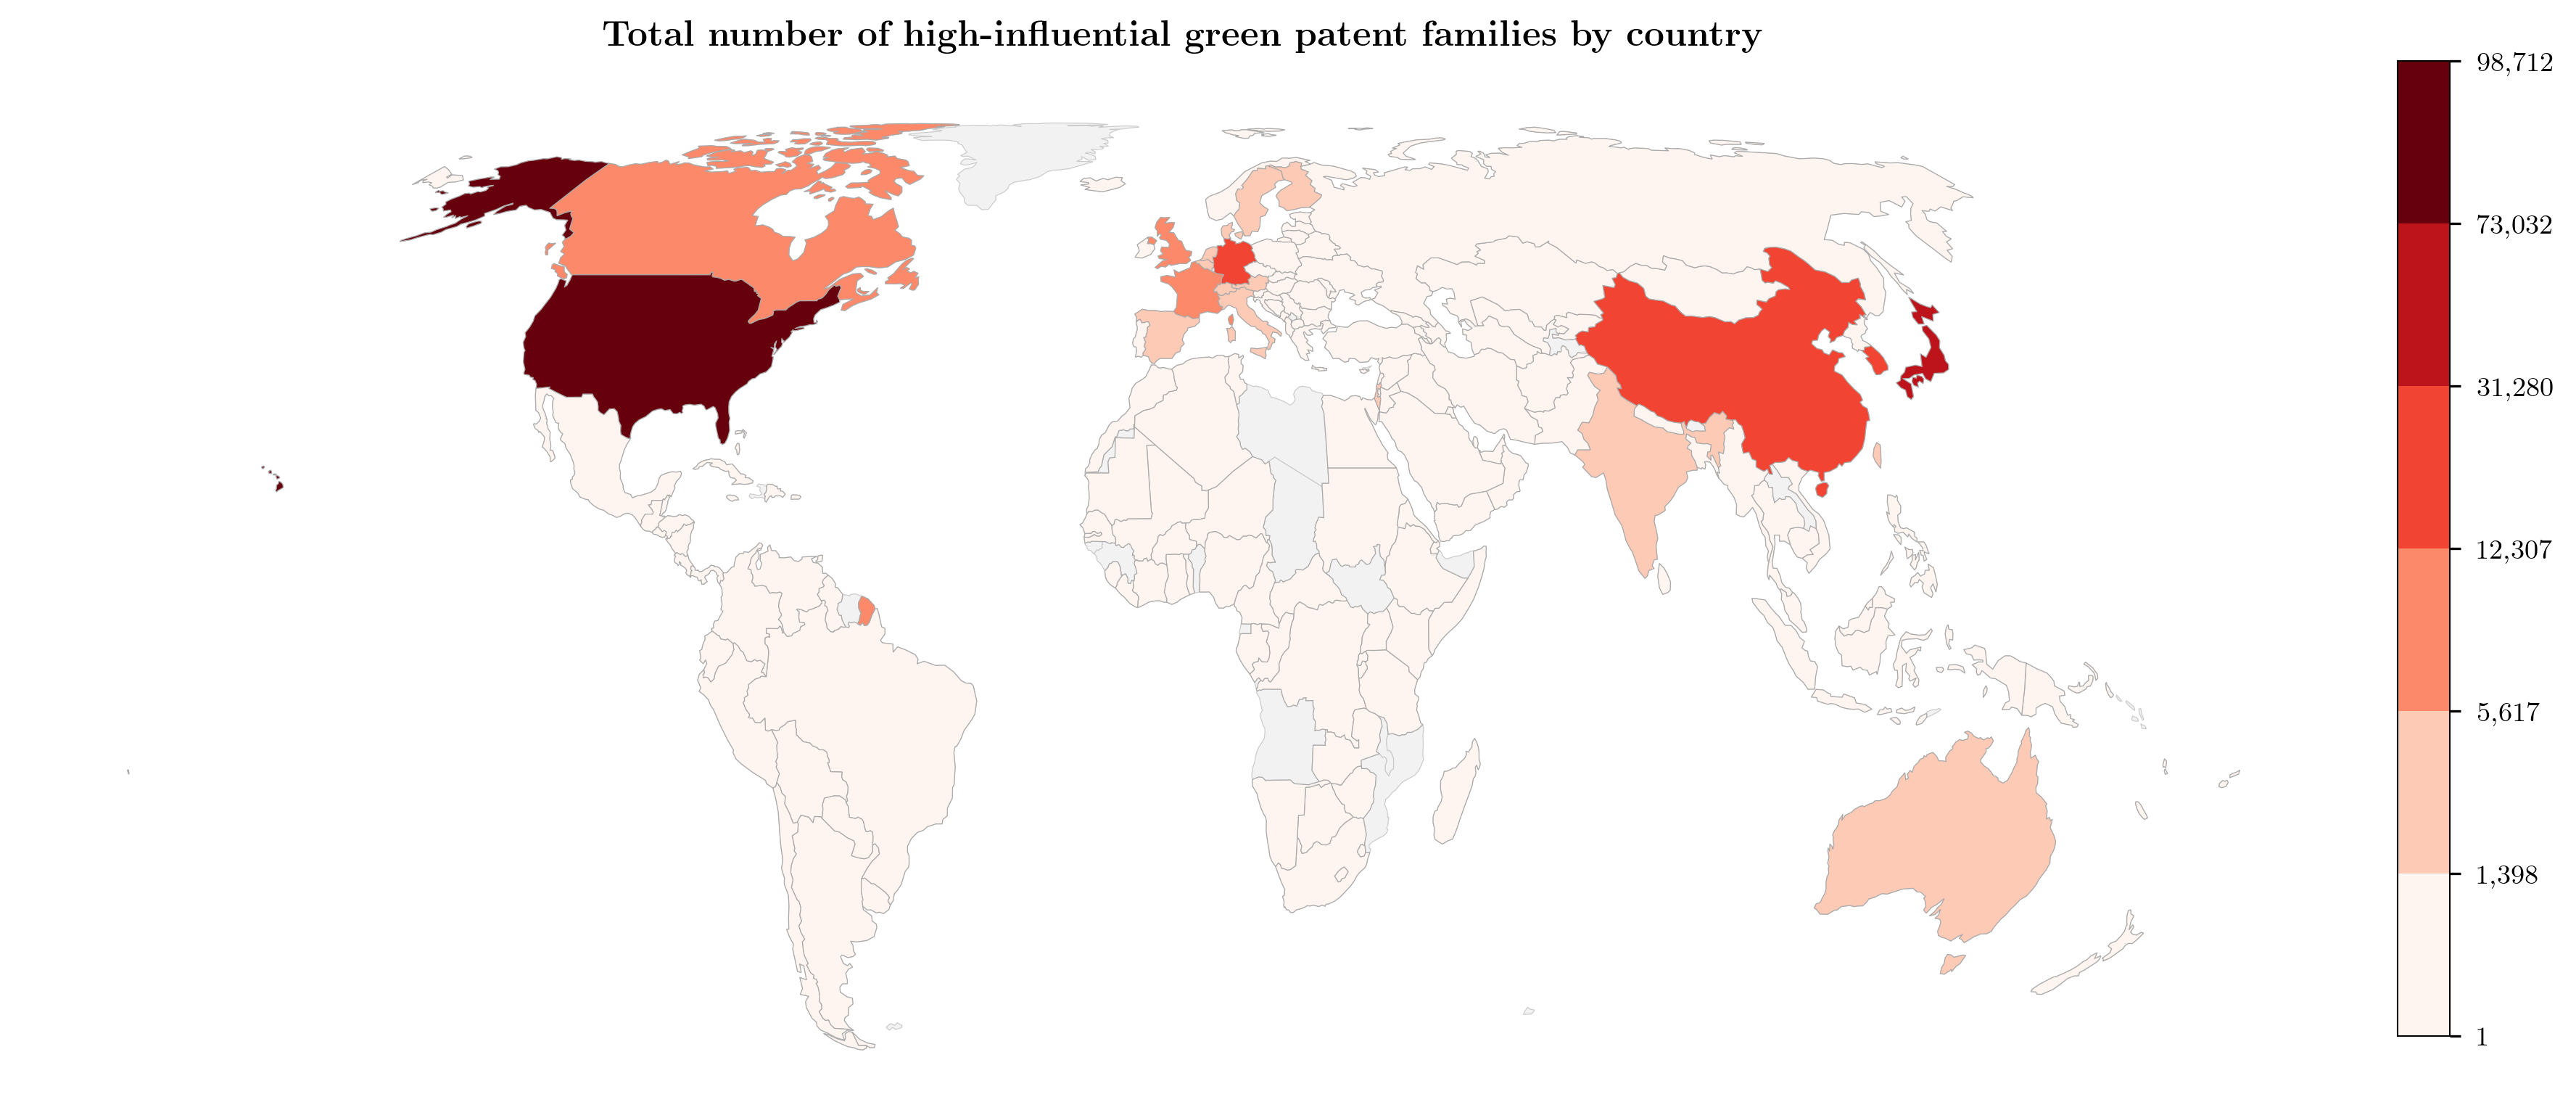

In [4]:
import polars as pl
import pycountry
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mapclassify

def to_iso3(code):
    try:
        c = pycountry.countries.get(alpha_2=code)
        return c.alpha_3 if c else None
    except:
        return None

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Computer Modern Roman"],
    "font.size": 11,
    "axes.titlesize": 12,
    "figure.dpi": 300,
})

world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = world[(world.pop_est > 0) & (world.name != "Antarctica")]

hi = pl.read_parquet("PATSTAT2025FALL\\output\\high_influence_green_patents.parquet")

df_hi = (
    hi
    .select(["docdb_family_id", "person_ctry_code"])
    .with_columns(pl.col("person_ctry_code").str.split(","))
    .explode("person_ctry_code")
    .with_columns(pl.col("person_ctry_code").str.strip_chars().alias("country"))
    .filter(pl.col("country").is_not_null() & (pl.col("country") != ""))
    .unique(subset=["docdb_family_id", "country"])
    .with_columns(
        pl.col("country").map_elements(to_iso3, return_dtype=pl.Utf8).alias("countries_3digit")
    )
    .filter(pl.col("countries_3digit").is_not_null())
    .group_by("countries_3digit")
    .agg(pl.col("docdb_family_id").n_unique().alias("num_patents"))
    .to_pandas()
)

valid = df_hi[df_hi['num_patents'] > 0]['num_patents']
classifier = mapclassify.NaturalBreaks(valid, k=6)
breaks = classifier.bins
print(f"High-influence Natural Breaks bins: {breaks}")

world_merged = world.merge(df_hi, left_on='iso_a3', right_on='countries_3digit', how='left')
world_proj = world_merged.to_crs('+proj=eqearth')

fig, ax = plt.subplots(1, 1, figsize=(12, 7))
world_proj.plot(ax=ax, color='#f2f2f2', edgecolor='#cccccc', linewidth=0.3)
world_proj.dropna(subset=['num_patents']).plot(
    ax=ax, column='num_patents', cmap='Reds',
    classification_kwds={'bins': breaks}, scheme='user_defined',
    edgecolor='#aaaaaa', linewidth=0.3, legend=False
)
ax.set_title(r"\textbf{Total number of high-influential green patent families by country}", fontsize=12, pad=10)
ax.set_axis_off()

cax = fig.add_axes([0.92, 0.18, 0.02, 0.64])
cmap = plt.cm.Reds
bounds = [valid.min()] + list(breaks)
norm_discrete = mcolors.BoundaryNorm(bounds, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_discrete)
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation='vertical', spacing='uniform')
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks(bounds)
cbar.set_ticklabels([f'{int(b):,}' for b in bounds])

plt.subplots_adjust(left=0.01, right=0.90, bottom=0.02, top=0.93)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_18900\3195198492.py:26: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


Neighbor Natural Breaks bins: [ 120557.  426648.  799418. 1997337. 2450408. 3197216.]


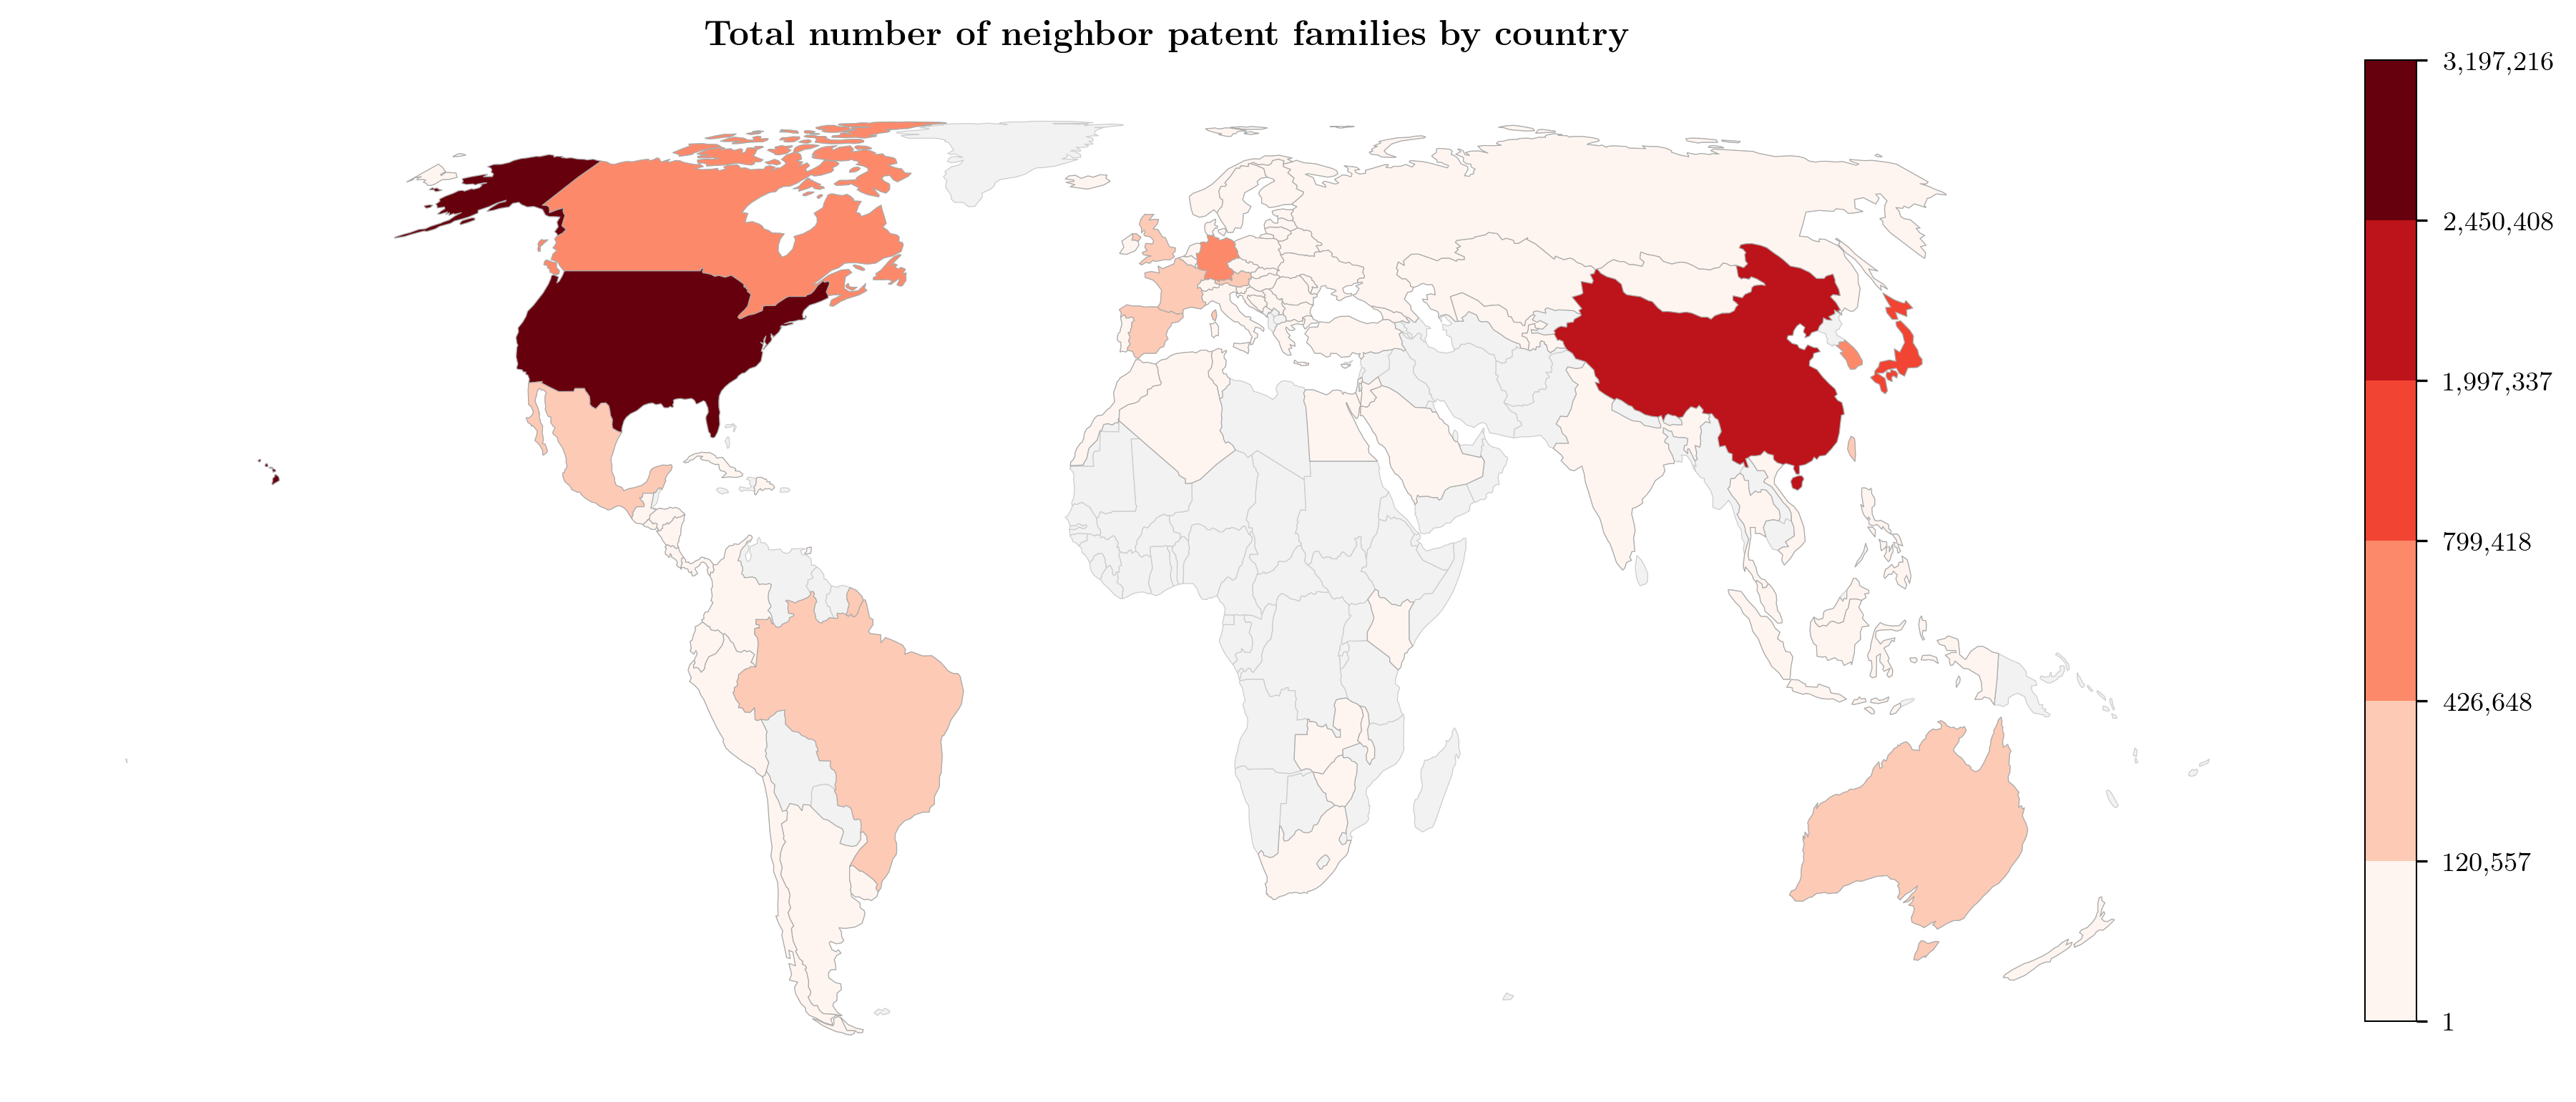

In [5]:
import polars as pl
import pycountry
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mapclassify

def to_iso3(code):
    try:
        c = pycountry.countries.get(alpha_2=code)
        return c.alpha_3 if c else None
    except:
        return None

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Computer Modern Roman"],
    "font.size": 11,
    "axes.titlesize": 12,
    "figure.dpi": 300,
})

world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = world[(world.pop_est > 0) & (world.name != "Antarctica")]

neighbor = pl.read_parquet("PATSTAT2025FALL\\output\\neighbor_families.parquet")

df_nb = (
    neighbor
    .select(["docdb_family_id", "appln_auth"])
    .with_columns(pl.col("appln_auth").str.split(","))
    .explode("appln_auth")
    .with_columns(pl.col("appln_auth").str.strip_chars().alias("country"))
    .filter(pl.col("country").is_not_null() & (pl.col("country") != ""))
    .with_columns(
        pl.col("country").map_elements(to_iso3, return_dtype=pl.Utf8).alias("countries_3digit")
    )
    .filter(pl.col("countries_3digit").is_not_null())
    .group_by("countries_3digit")
    .agg(pl.col("docdb_family_id").n_unique().alias("num_patents"))
    .to_pandas()
)

valid = df_nb[df_nb['num_patents'] > 0]['num_patents']
classifier = mapclassify.NaturalBreaks(valid, k=6)
breaks = classifier.bins
print(f"Neighbor Natural Breaks bins: {breaks}")

world_merged = world.merge(df_nb, left_on='iso_a3', right_on='countries_3digit', how='left')
world_proj = world_merged.to_crs('+proj=eqearth')

fig, ax = plt.subplots(1, 1, figsize=(12, 7))
world_proj.plot(ax=ax, color='#f2f2f2', edgecolor='#cccccc', linewidth=0.3)
world_proj.dropna(subset=['num_patents']).plot(
    ax=ax, column='num_patents', cmap='Reds',
    classification_kwds={'bins': breaks}, scheme='user_defined',
    edgecolor='#aaaaaa', linewidth=0.3, legend=False
)
ax.set_title(r"\textbf{Total number of neighbor patent families by country}", fontsize=12, pad=10)
ax.set_axis_off()

cax = fig.add_axes([0.92, 0.18, 0.02, 0.64])
cmap = plt.cm.Reds
bounds = [valid.min()] + list(breaks)
norm_discrete = mcolors.BoundaryNorm(bounds, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_discrete)
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation='vertical', spacing='uniform')
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks(bounds)
cbar.set_ticklabels([f'{int(b):,}' for b in bounds])

plt.subplots_adjust(left=0.01, right=0.90, bottom=0.02, top=0.93)
plt.show()

In [56]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ==========================================
# 1. 設置學術風格
# ==========================================
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Computer Modern Roman"],
    "font.size": 11,
    "axes.titlesize": 12,
    "figure.dpi": 300,
})

# ==========================================
# 2. 數據處理
# ==========================================
# 讀取地圖
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = world[(world.pop_est > 0) & (world.name != "Antarctica")]

# 讀取專利質量數據
df_quality = pd.read_csv("oecd_patent_quality_country_year_complete.csv")
# 讀取專利數量數據（用於計算前99%）
df_count = pd.read_excel("expanded_patent_count8722.xlsx")

# 確保年份列名正確
year_col = 'earliest_year'
if year_col not in df_count.columns:
    for col in df_count.columns:
        if 'year' in col.lower():
            year_col = col
            break

# 重命名列以便合併
df_count_renamed = df_count.rename(columns={year_col: 'appln_filing_year'})
time_periods = [
    ([1987, 1988, 1989, 1990], "1987-1990"),
    ([1991, 1992, 1993, 1994, 1995], "1991-1995"),
    ([1996, 1997, 1998, 1999, 2000], "1996-2000"),
    ([2001, 2002, 2003, 2004, 2005], "2001-2005"),
    ([2006, 2007, 2008, 2009, 2010], "2006-2010"),
    ([2011, 2012, 2013, 2014, 2015], "2011-2015"),
    ([2016, 2017, 2018, 2019], "2016-2019"),
    ([2020, 2021, 2022], "2020-2022")
]

C:\Users\admin\AppData\Local\Temp\ipykernel_34108\3890513391.py:24: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


In [57]:
# ==========================================
# 3. 為每個時間段計算平均質量指數（僅前99%國家）
# ==========================================
period_data = []

for years, label in time_periods:
    # 步驟1: 篩選該時間段的專利數量數據，計算每個國家的總專利數
    df_count_period = df_count_renamed[
        df_count_renamed['appln_filing_year'].isin(years)
    ].copy()
    
    country_patent_sum = df_count_period.groupby('countries_3digit').agg({
        'num_patents': 'sum'
    }).reset_index()
    
    # 步驟2: 按專利數量排序，計算累計百分比，找出前99%的國家
    country_patent_sum = country_patent_sum.sort_values('num_patents', ascending=False)
    country_patent_sum['cumsum'] = (
        country_patent_sum['num_patents'].cumsum() / country_patent_sum['num_patents'].sum()
    )
    
    # 只保留累計百分比 <= 0.99 的國家（前99%專利來源國）
    valid_countries = country_patent_sum[
        country_patent_sum['cumsum'] <= 0.99
    ]['countries_3digit'].tolist()
    
    # 步驟3: 篩選該時間段的質量數據，只保留前99%國家
    df_quality_period = df_quality[
        (df_quality['family_year'].isin(years)) &
        (df_quality['country_code_3digit'].isin(valid_countries))
    ].copy()
    
    # 步驟4: 計算這些國家的平均質量指數（只考慮有專利的年份）
    country_quality = df_quality_period[
        df_quality_period['country_patent_quality_index'] > 0
    ].groupby('country_code_3digit').agg({
        'country_patent_quality_index': 'mean'
    }).reset_index()
    
    # 步驟5: 合併專利數量信息（用於記錄）
    country_period = country_quality.merge(
        country_patent_sum[['countries_3digit', 'num_patents', 'cumsum']],
        left_on='country_code_3digit',
        right_on='countries_3digit',
        how='left'
    )
    
    # 添加時間段標籤
    country_period['period'] = label
    period_data.append(country_period)

# 合併所有時間段數據
df_all_periods = pd.concat(period_data, ignore_index=True)

# 計算全局最大值和最小值（用於統一色階）
valid_quality = df_all_periods['country_patent_quality_index'].dropna()
quality_min = valid_quality.min()
quality_max = valid_quality.max()

import mapclassify
classifier = mapclassify.NaturalBreaks(valid_quality, k=5)
breaks = classifier.bins

print(f"Natural Breaks classification bins: {breaks}")

Natural Breaks classification bins: [0.14389146 0.19835169 0.23847583 0.27679358 0.36254707]


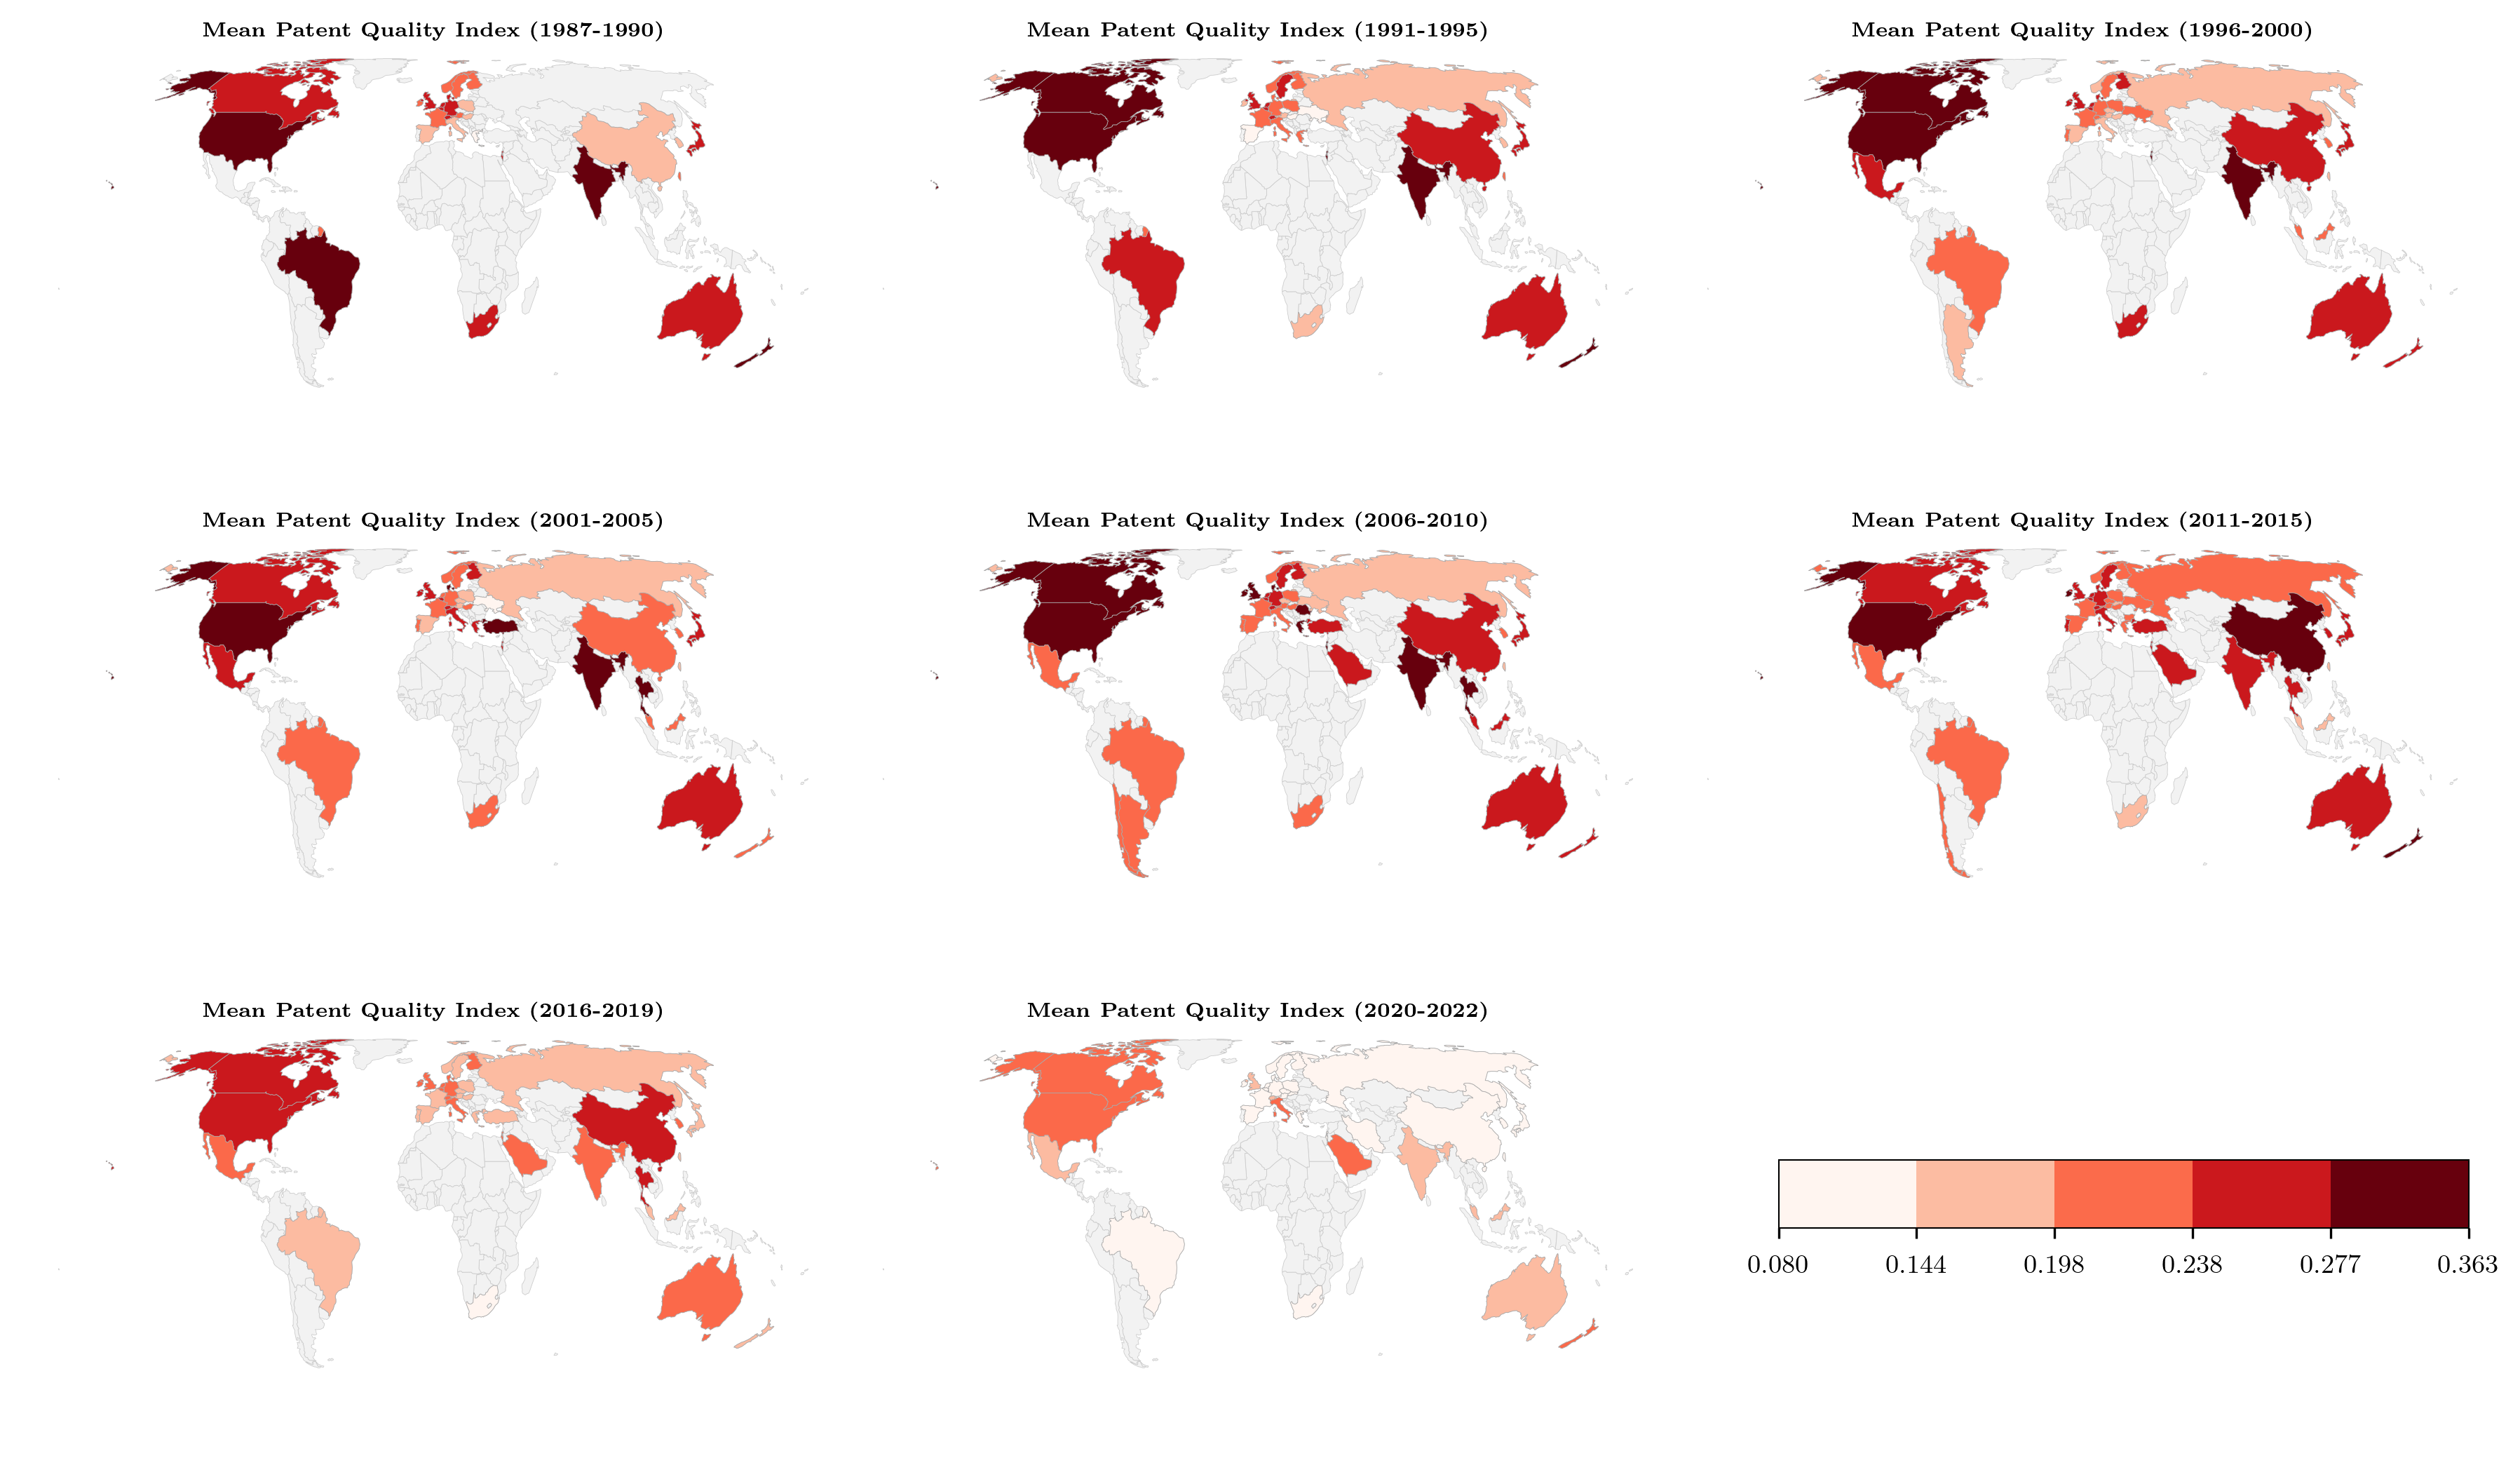

In [ ]:
# ==========================================
# 4. 繪製 Small Multiples (2行3列)
# ==========================================
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for i, (years, label) in enumerate(time_periods):
    ax = axes[i]
    
    # 獲取該時間段的數據
    df_period = df_all_periods[df_all_periods['period'] == label].copy()
    
    # 合併到地圖數據
    world_merged = world.merge(
        df_period[['country_code_3digit', 'country_patent_quality_index']], 
        left_on='iso_a3', 
        right_on='country_code_3digit', 
        how='left'
    )
    
    # 投影轉換 (Equal Earth)
    world_proj = world_merged.to_crs('+proj=eqearth')
    
    # --- 繪圖 ---
    # 1. 繪製底圖 (淺灰)
    world_proj.plot(ax=ax, color='#f2f2f2', edgecolor='#cccccc', linewidth=0.2)
    
    # 2. 繪製數據 (Choropleth with Natural Breaks)
    world_proj.dropna(subset=['country_patent_quality_index']).plot(
        ax=ax,
        column='country_patent_quality_index',
        cmap='Reds',
        classification_kwds={'bins': breaks},  # 使用全局統一的斷點
        scheme='user_defined',  # 使用自定義斷點
        edgecolor='#aaaaaa',
        linewidth=0.2,
        legend=False
    )
    
    # 3. 設置標題和移除坐標軸
    ax.set_title(
        fr"\textbf{{Mean Patent Quality Index ({label})}}",
        fontsize=7,
        pad=2
    )
    ax.set_axis_off()

# ==========================================
# 5. 添加統一 Colorbar (使用 Natural Breaks 的斷點)
# ==========================================
# Hide the 9th subplot's default axes
# axes[8].set_axis_off()

# # Use the 9th cell's position for the colorbar
# pos = axes[8].get_position()
cax = fig.add_axes([0.92, 0.12, 0.02, 0.76])

# 創建離散色階
cmap = plt.cm.Reds
bounds = [quality_min] + list(breaks)
norm_discrete = mcolors.BoundaryNorm(bounds, cmap.N)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_discrete)
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', spacing='uniform')

# Colorbar 樣式
# cbar.set_label(
#     r'\textbf{Patent Quality Index}',
#     rotation=270,
#     labelpad=20,
#     fontsize=10
# )
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(labelsize=9)

# 設置刻度標籤為斷點值
cbar.set_ticks(bounds)
cbar.set_ticklabels([f'{b:.3f}' for b in bounds])

# 調整佈局
plt.subplots_adjust(wspace=0.0, hspace=0.05, left=0.01, right=0.99, bottom=0.02)

# 添加說明文字
# fig.text(
#     0.46, 0.02,
#     r'\textit{Note: Only countries contributing to top 99\% of patents in each period are shown}',
#     ha='center',
#     fontsize=8,
#     style='italic'
# )

plt.show()